### Multiplot for any rho experiment for a timeseries

In [6]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

In [7]:
dataf ="/Volumes/ESA_F4R/ed_prepare/2026_mergeds/" 
datao ="/Volumes/ESA_F4R/ed_prepare/2026_rho/bands_rho/" 
datap ="/Volumes/ESA_F4R/ed_prepare/2026_plots/bands_rho/" 
datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"congo_basin_evergreen.shp")

S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_HI" # L_M or L_HI

In [8]:
rho_xarr={}
for B in ['N','S','EQ']:
    print('running band:', B)
    rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc")
    print(rho_xarr[B])

running band: N
<xarray.Dataset> Size: 27MB
Dimensions:  (rot: 4, time: 360, lat: 28, lon: 84)
Coordinates:
  * rot      (rot) int64 32B 1 2 3 4
  * lon      (lon) float64 672B 10.12 10.38 10.62 10.88 ... 30.38 30.62 30.88
  * lat      (lat) float64 224B 5.125 5.375 5.625 5.875 ... 11.38 11.62 11.88
  * time     (time) datetime64[ns] 3kB 1990-01-01 1990-02-01 ... 2024-12-01
Data variables:
    rho      (rot, time, lat, lon) float64 27MB dask.array<chunksize=(4, 12, 28, 84), meta=np.ndarray>
Attributes:
    description:  Recycling ratio
    units:        %
running band: S
<xarray.Dataset> Size: 1MB
Dimensions:  (rot: 4, time: 12, lat: 40, lon: 76)
Coordinates:
  * rot      (rot) int64 32B 1 2 3 4
  * lon      (lon) float64 608B 12.12 12.38 12.62 12.88 ... 30.38 30.62 30.88
  * lat      (lat) float64 320B -14.88 -14.62 -14.38 ... -5.625 -5.375 -5.125
  * time     (time) datetime64[ns] 96B 2010-01-01 2010-02-01 ... 2010-12-01
Data variables:
    rho      (rot, time, lat, lon) float64 1MB 

In [9]:
#    #Filtering out outliers for plotting 
#    for B in ['N']:
#        for r in np.arange(1,5):
#            print("*** Rotation is: ",r)
#            try:
#                print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#                print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#                rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<=1.0,1.0)
#                rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>0.0,0.0)
#                print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#                print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#                print('-------------------------')
#            except:
#                print('No outliers')
#                print(rho_xarr[B])

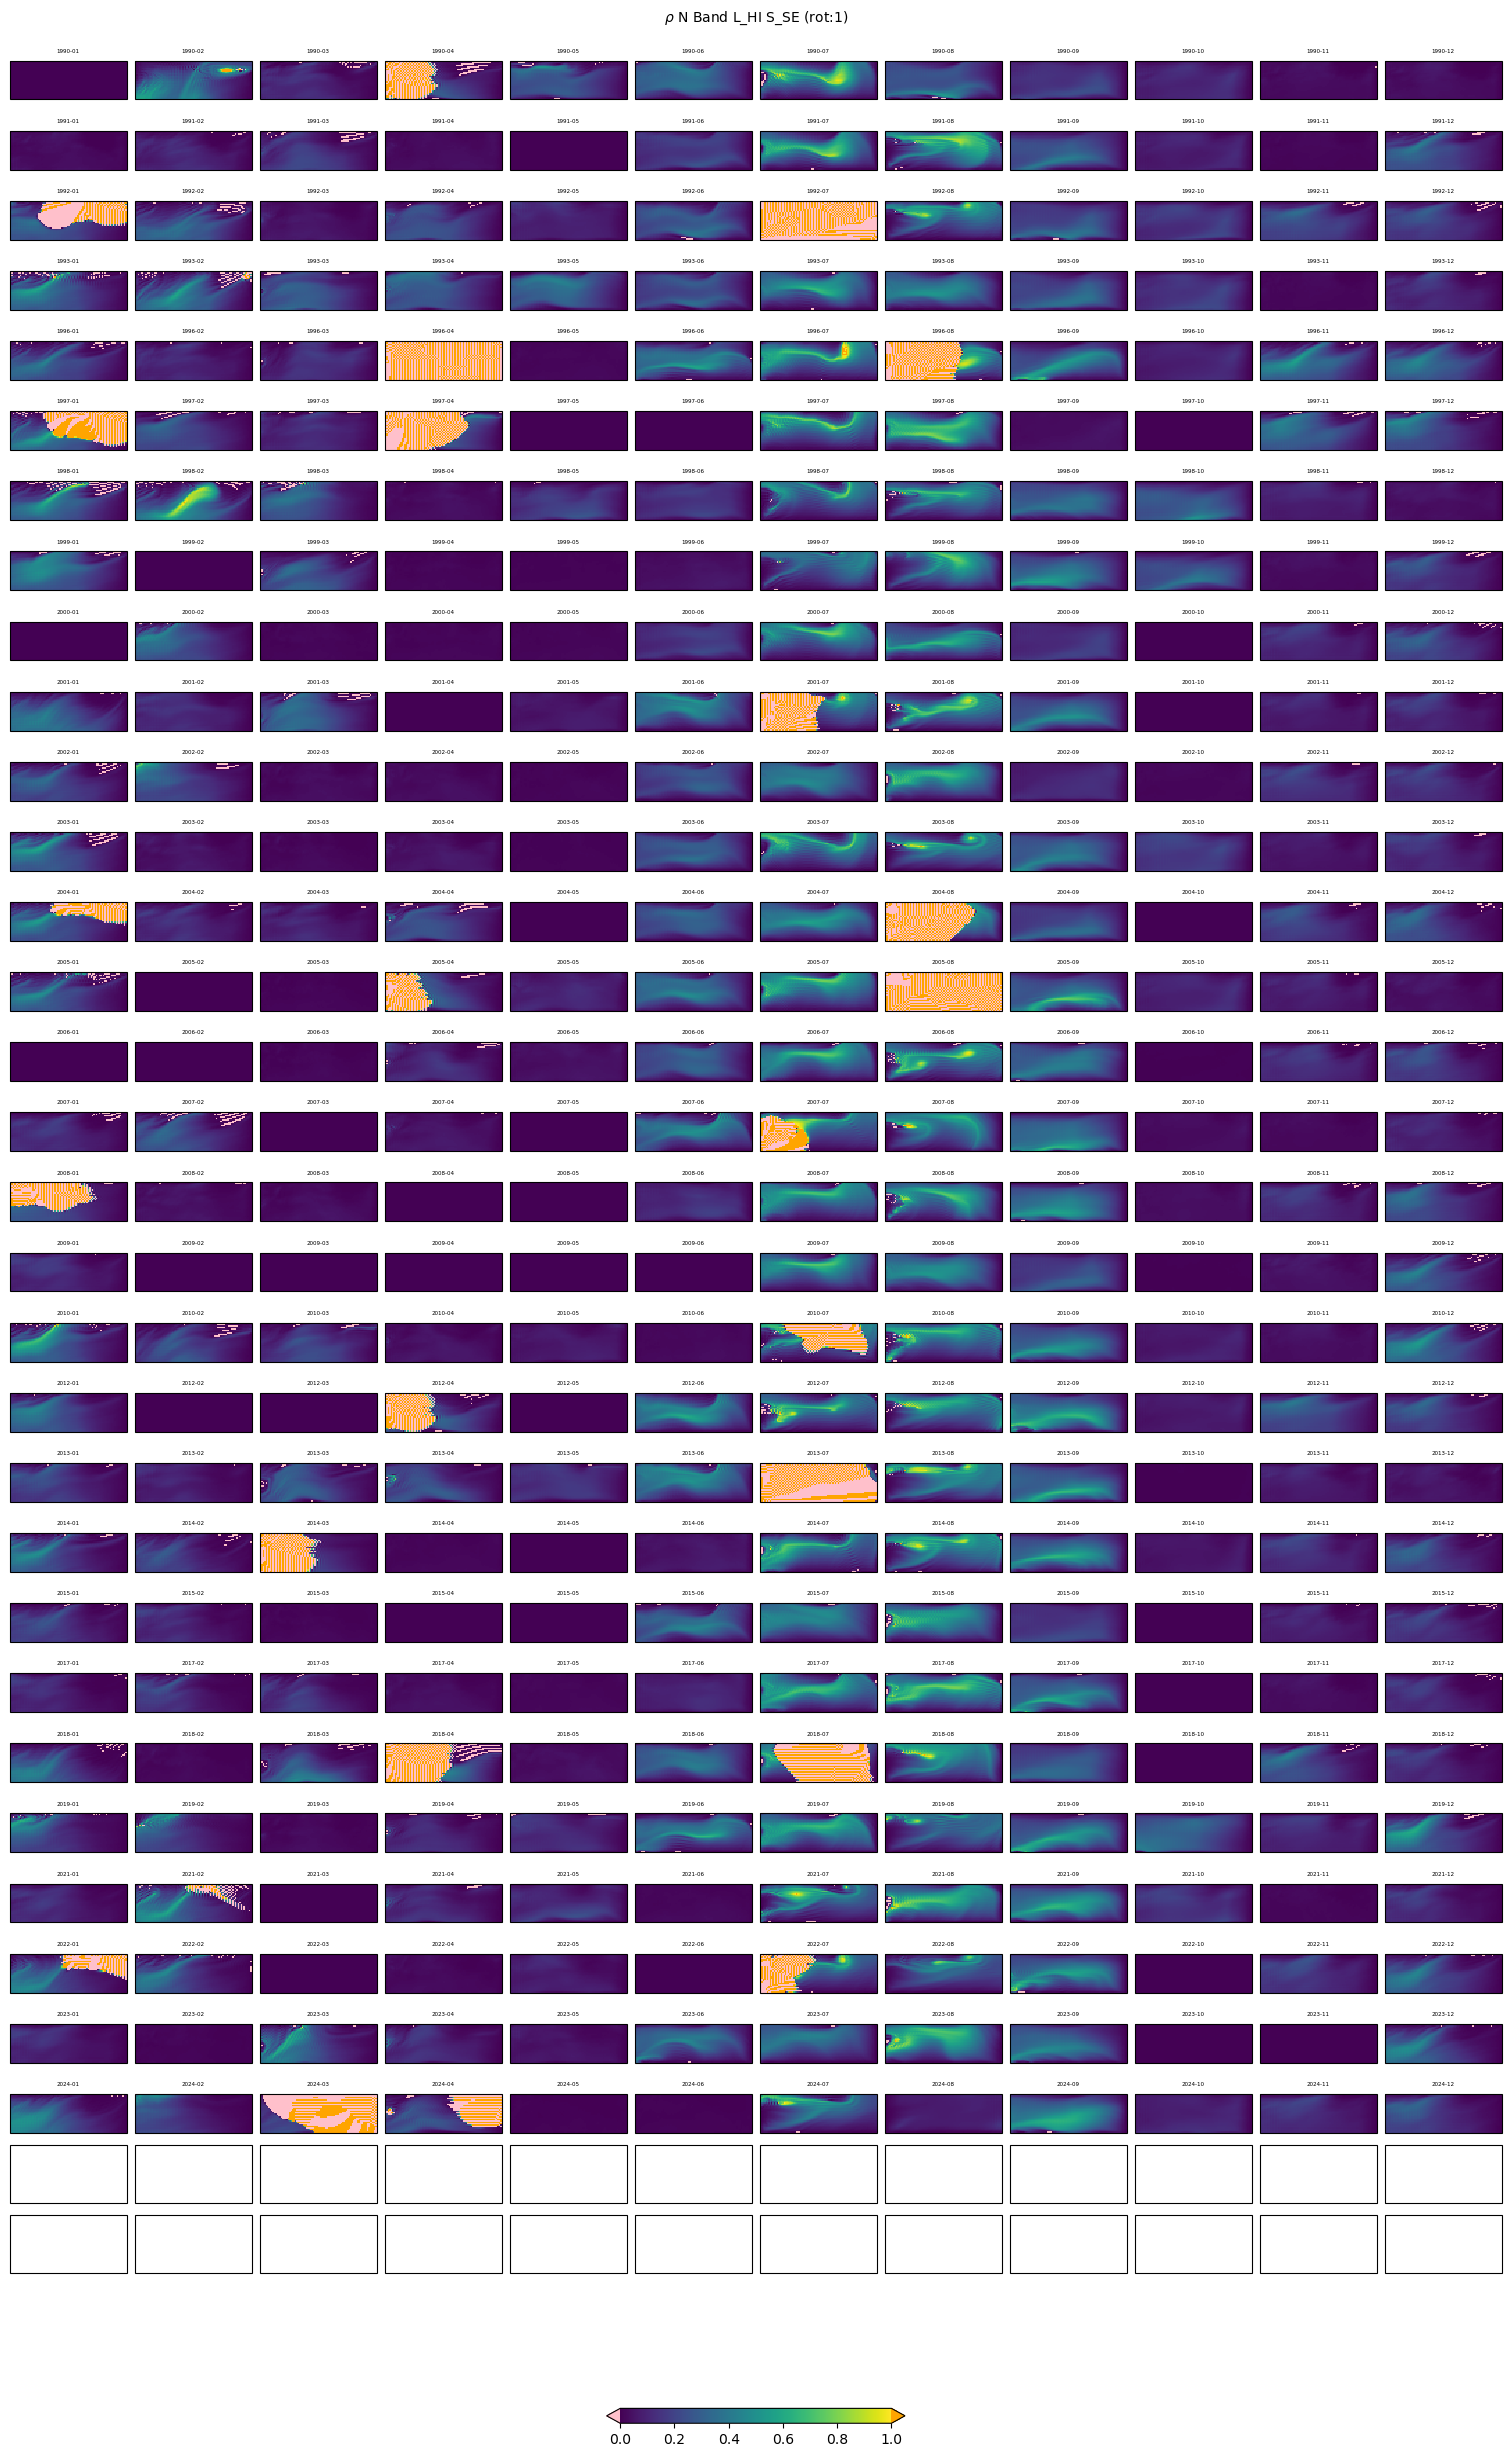

<Figure size 640x480 with 0 Axes>

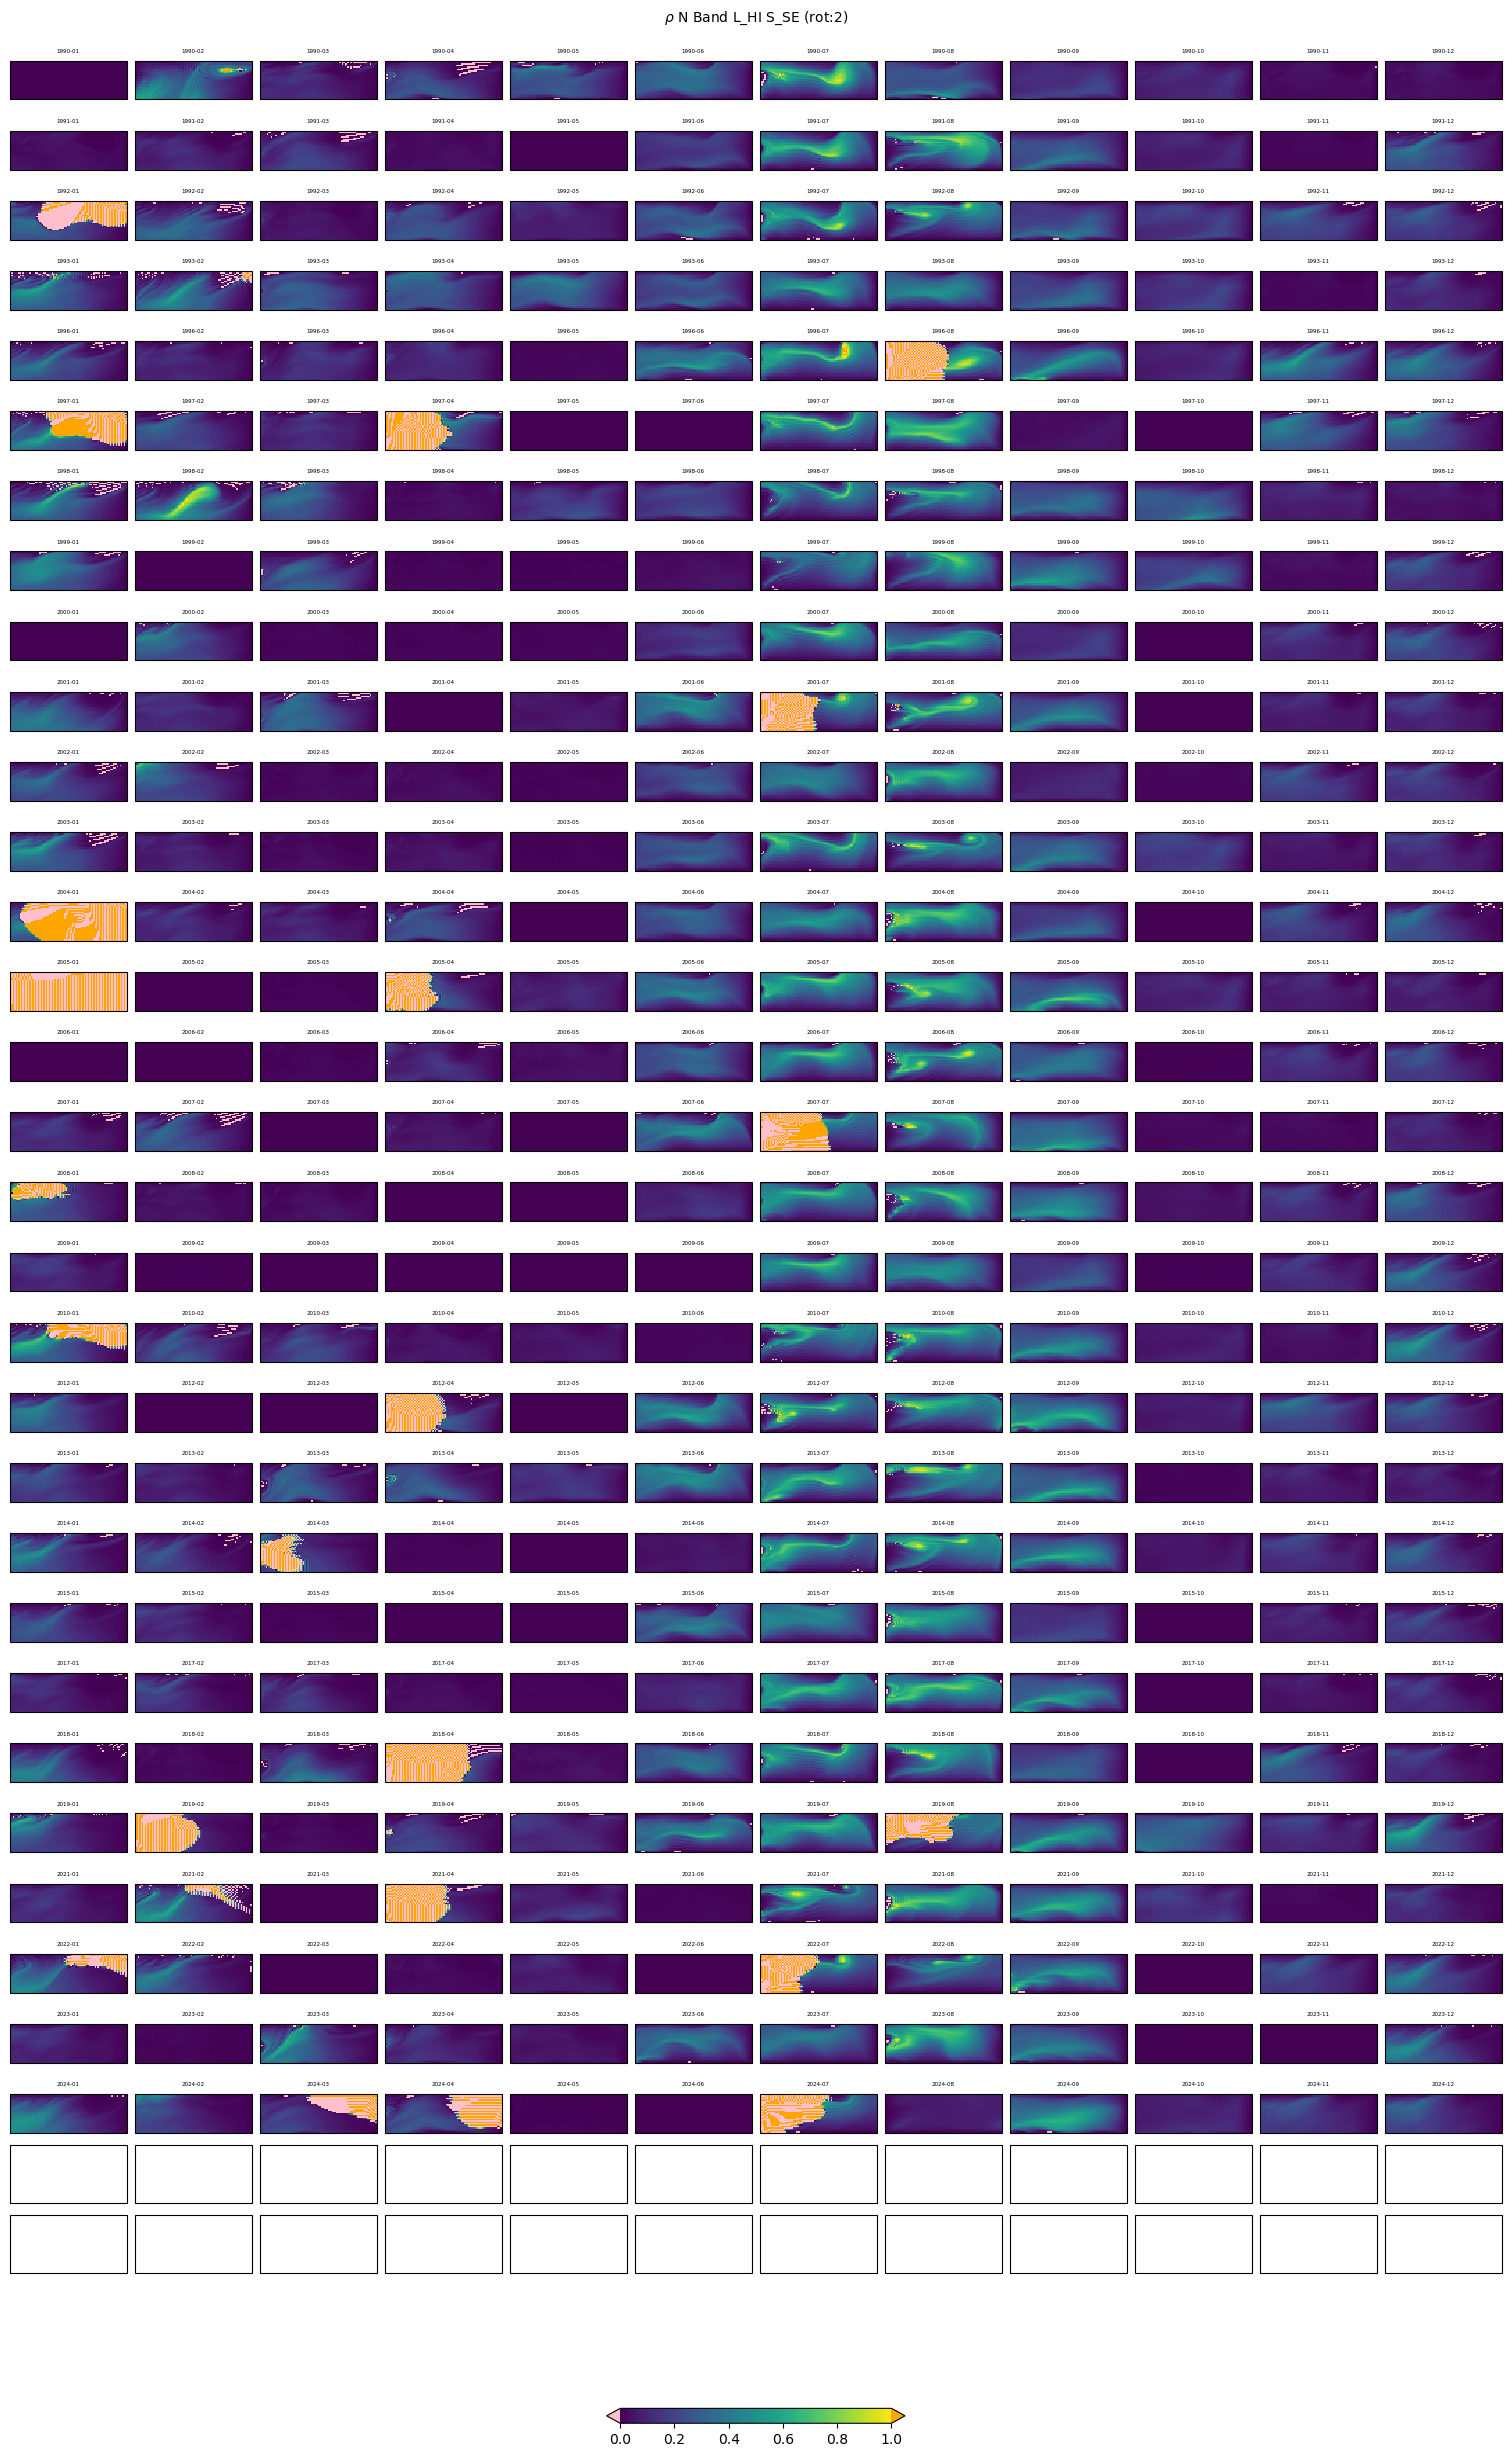

<Figure size 640x480 with 0 Axes>

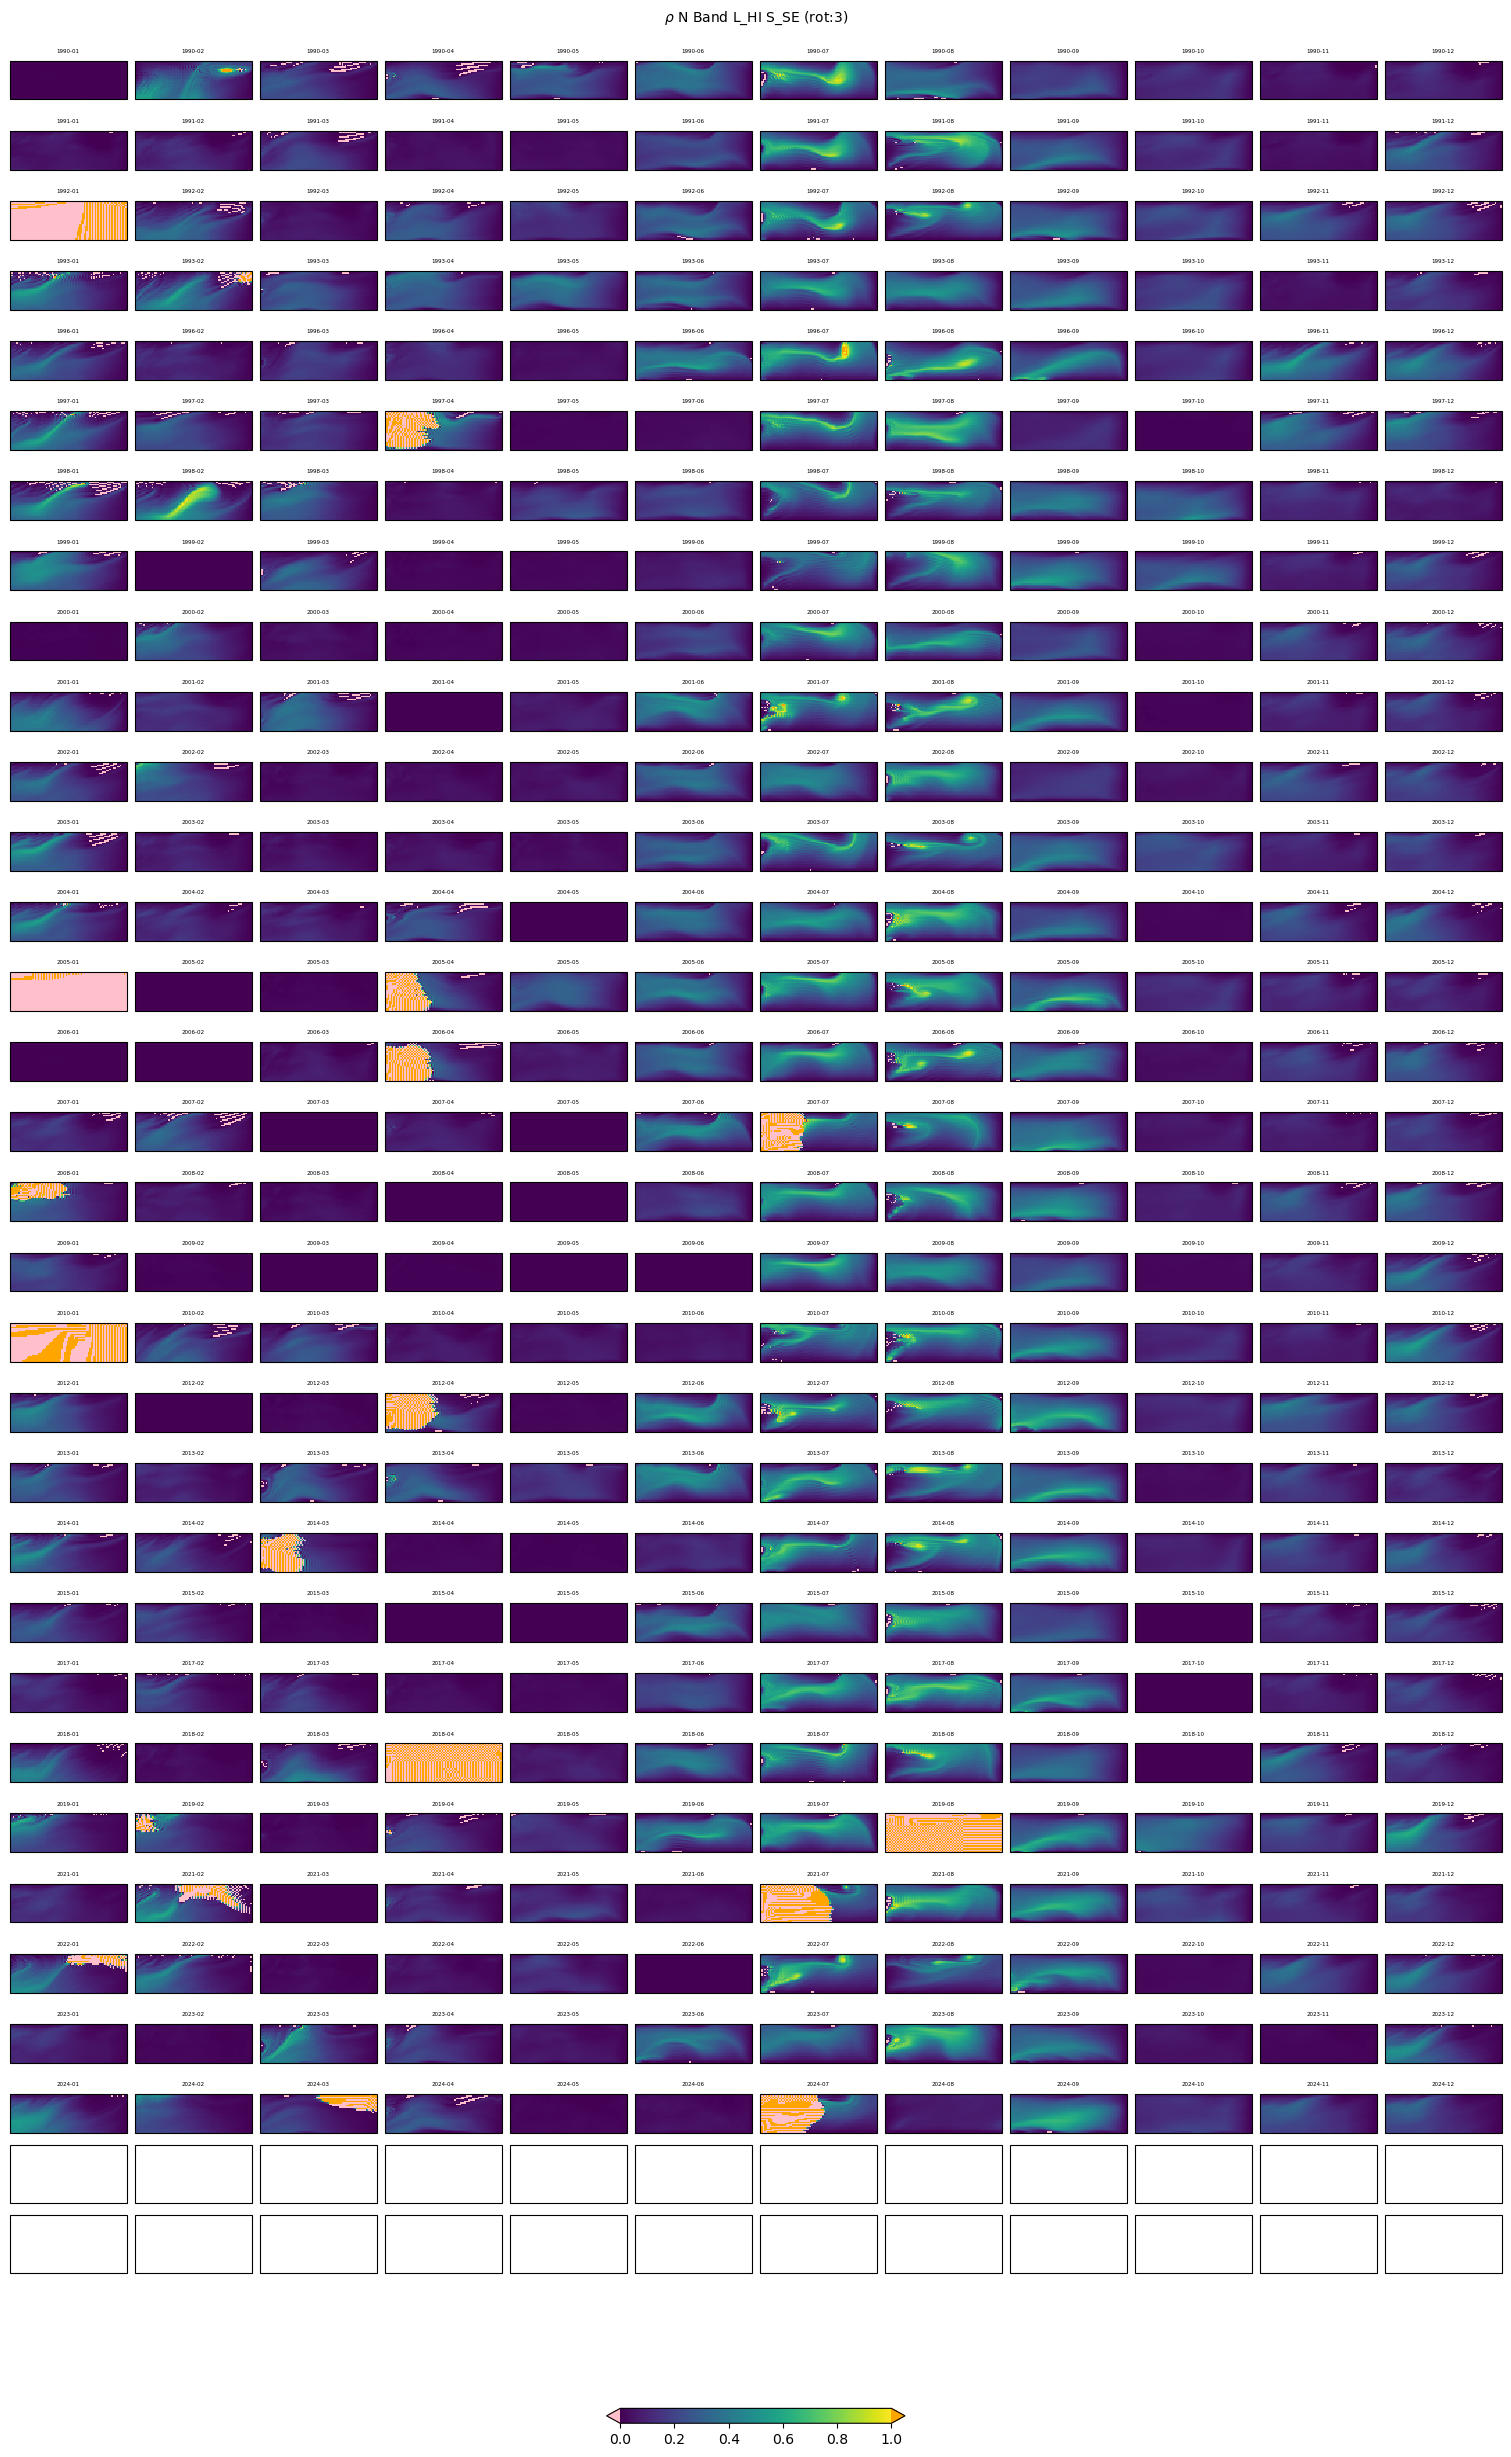

<Figure size 640x480 with 0 Axes>

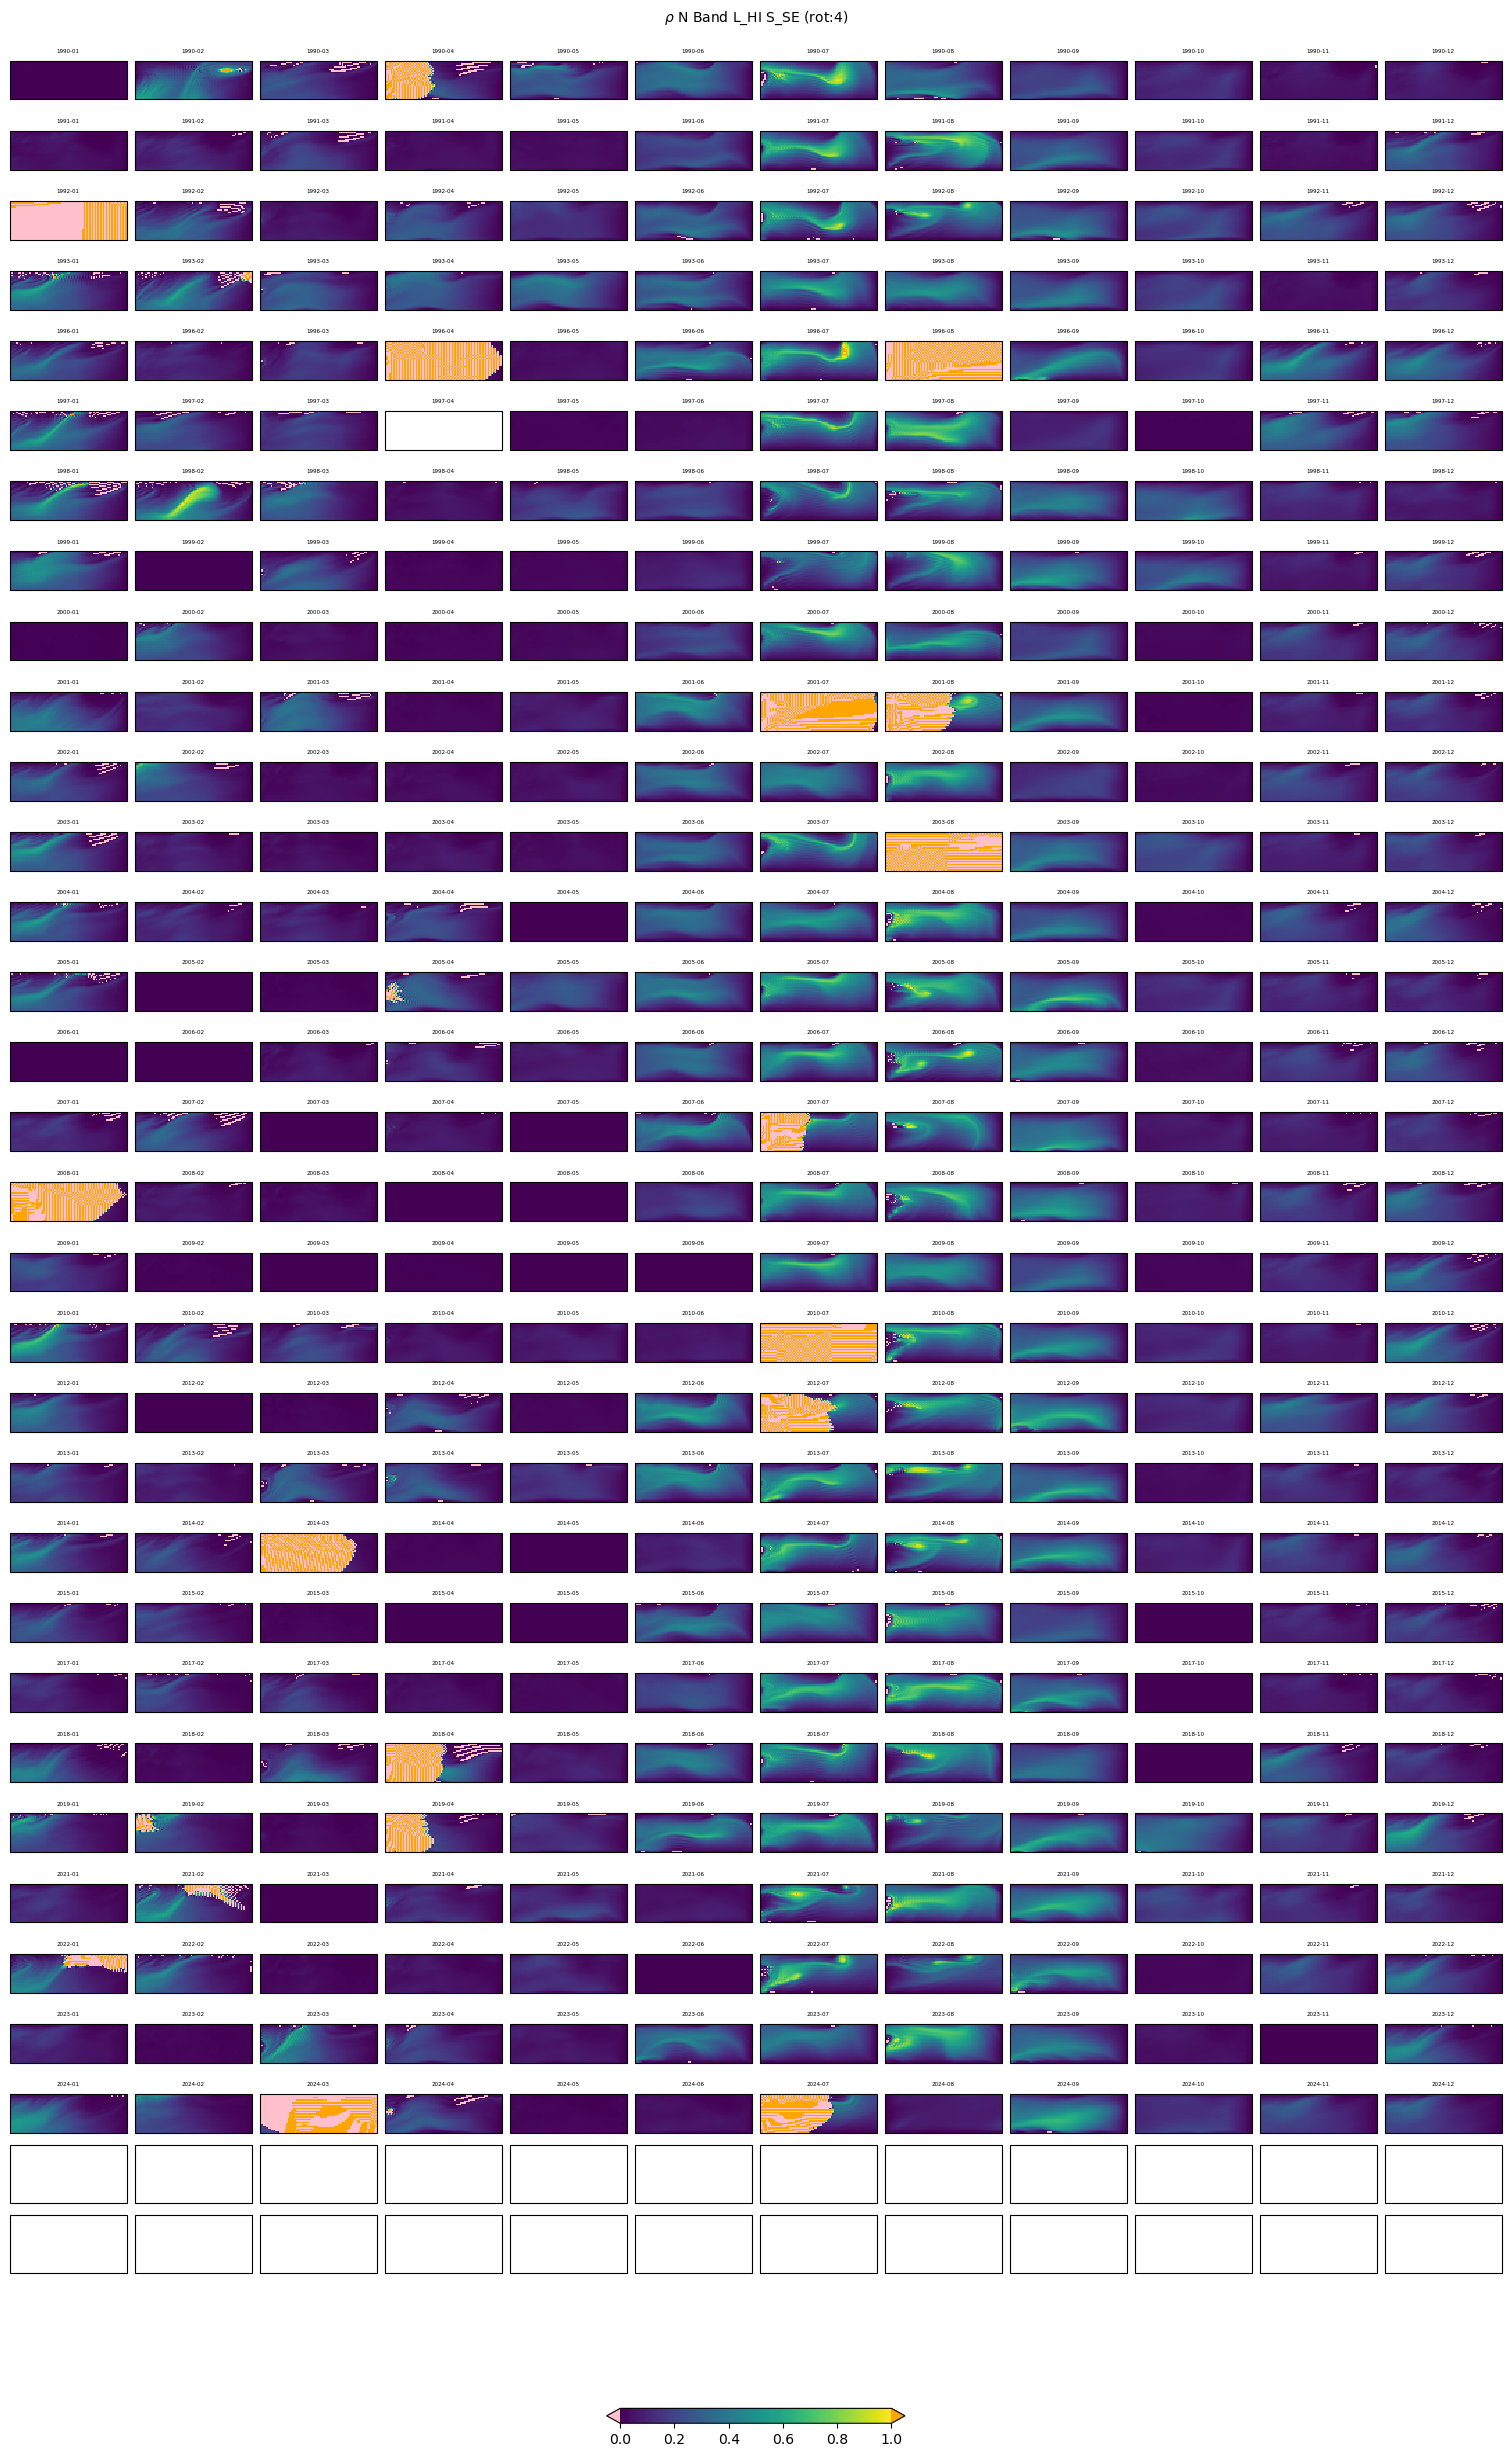

<Figure size 640x480 with 0 Axes>

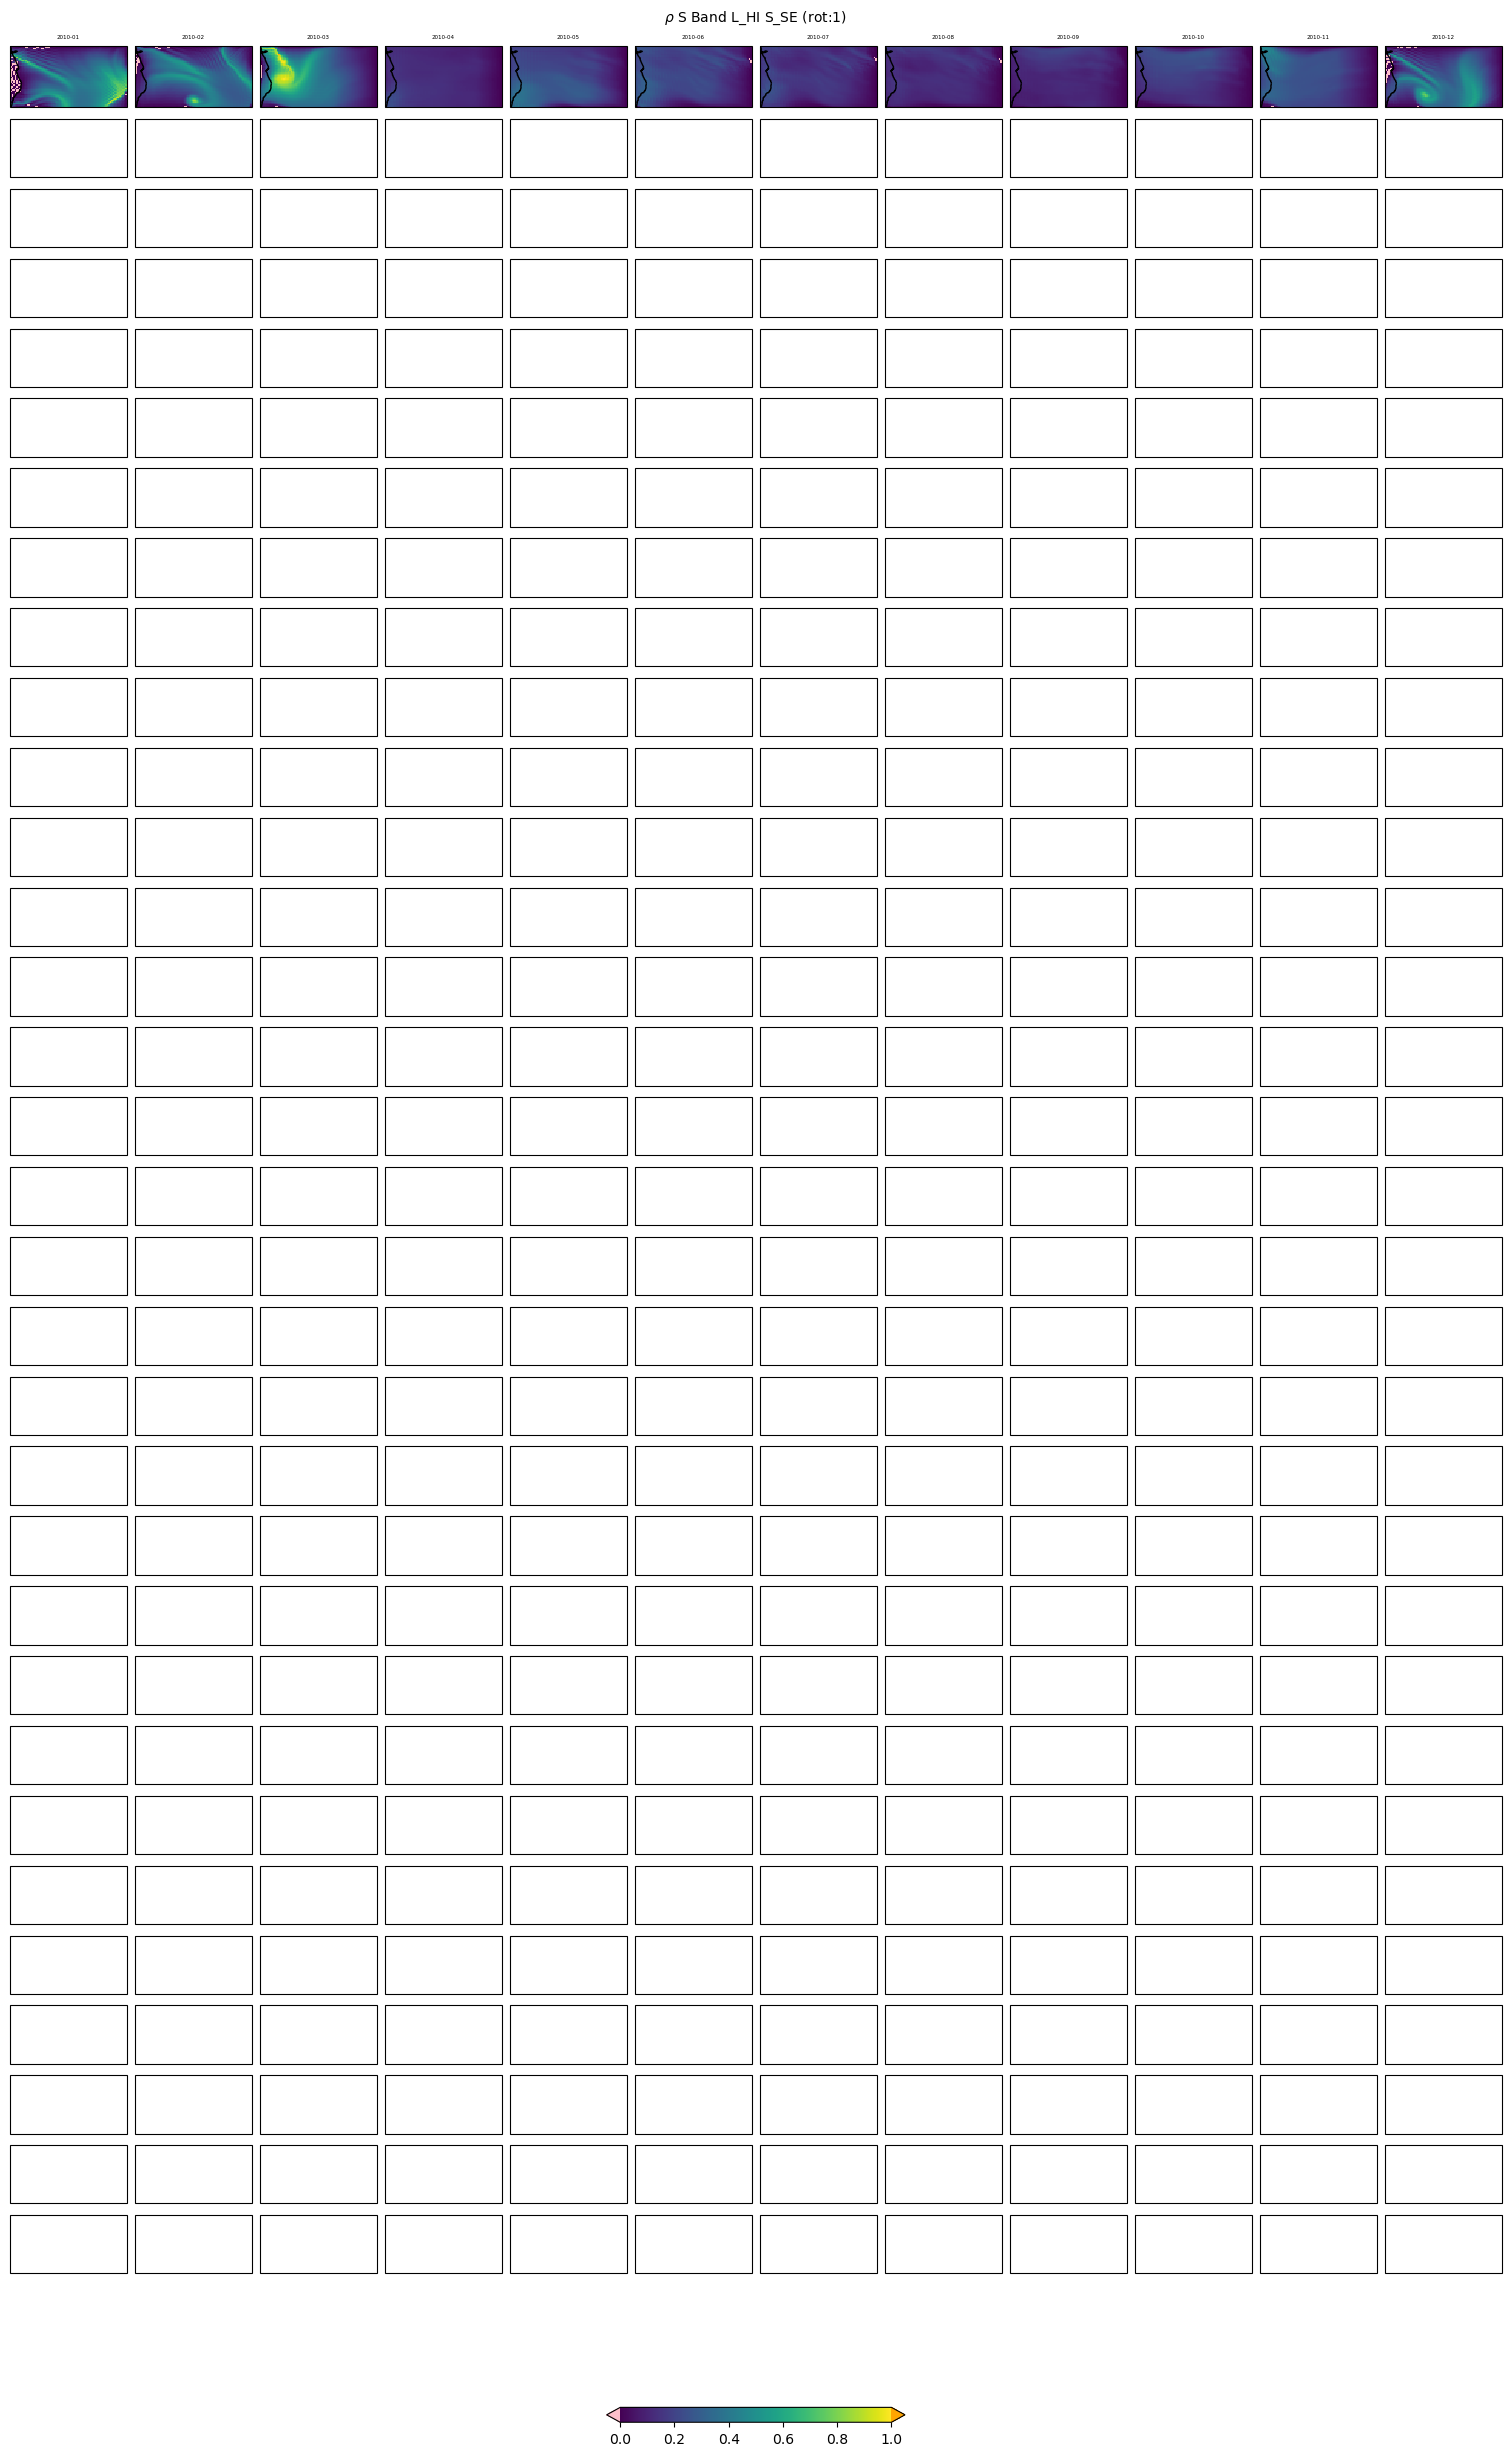

<Figure size 640x480 with 0 Axes>

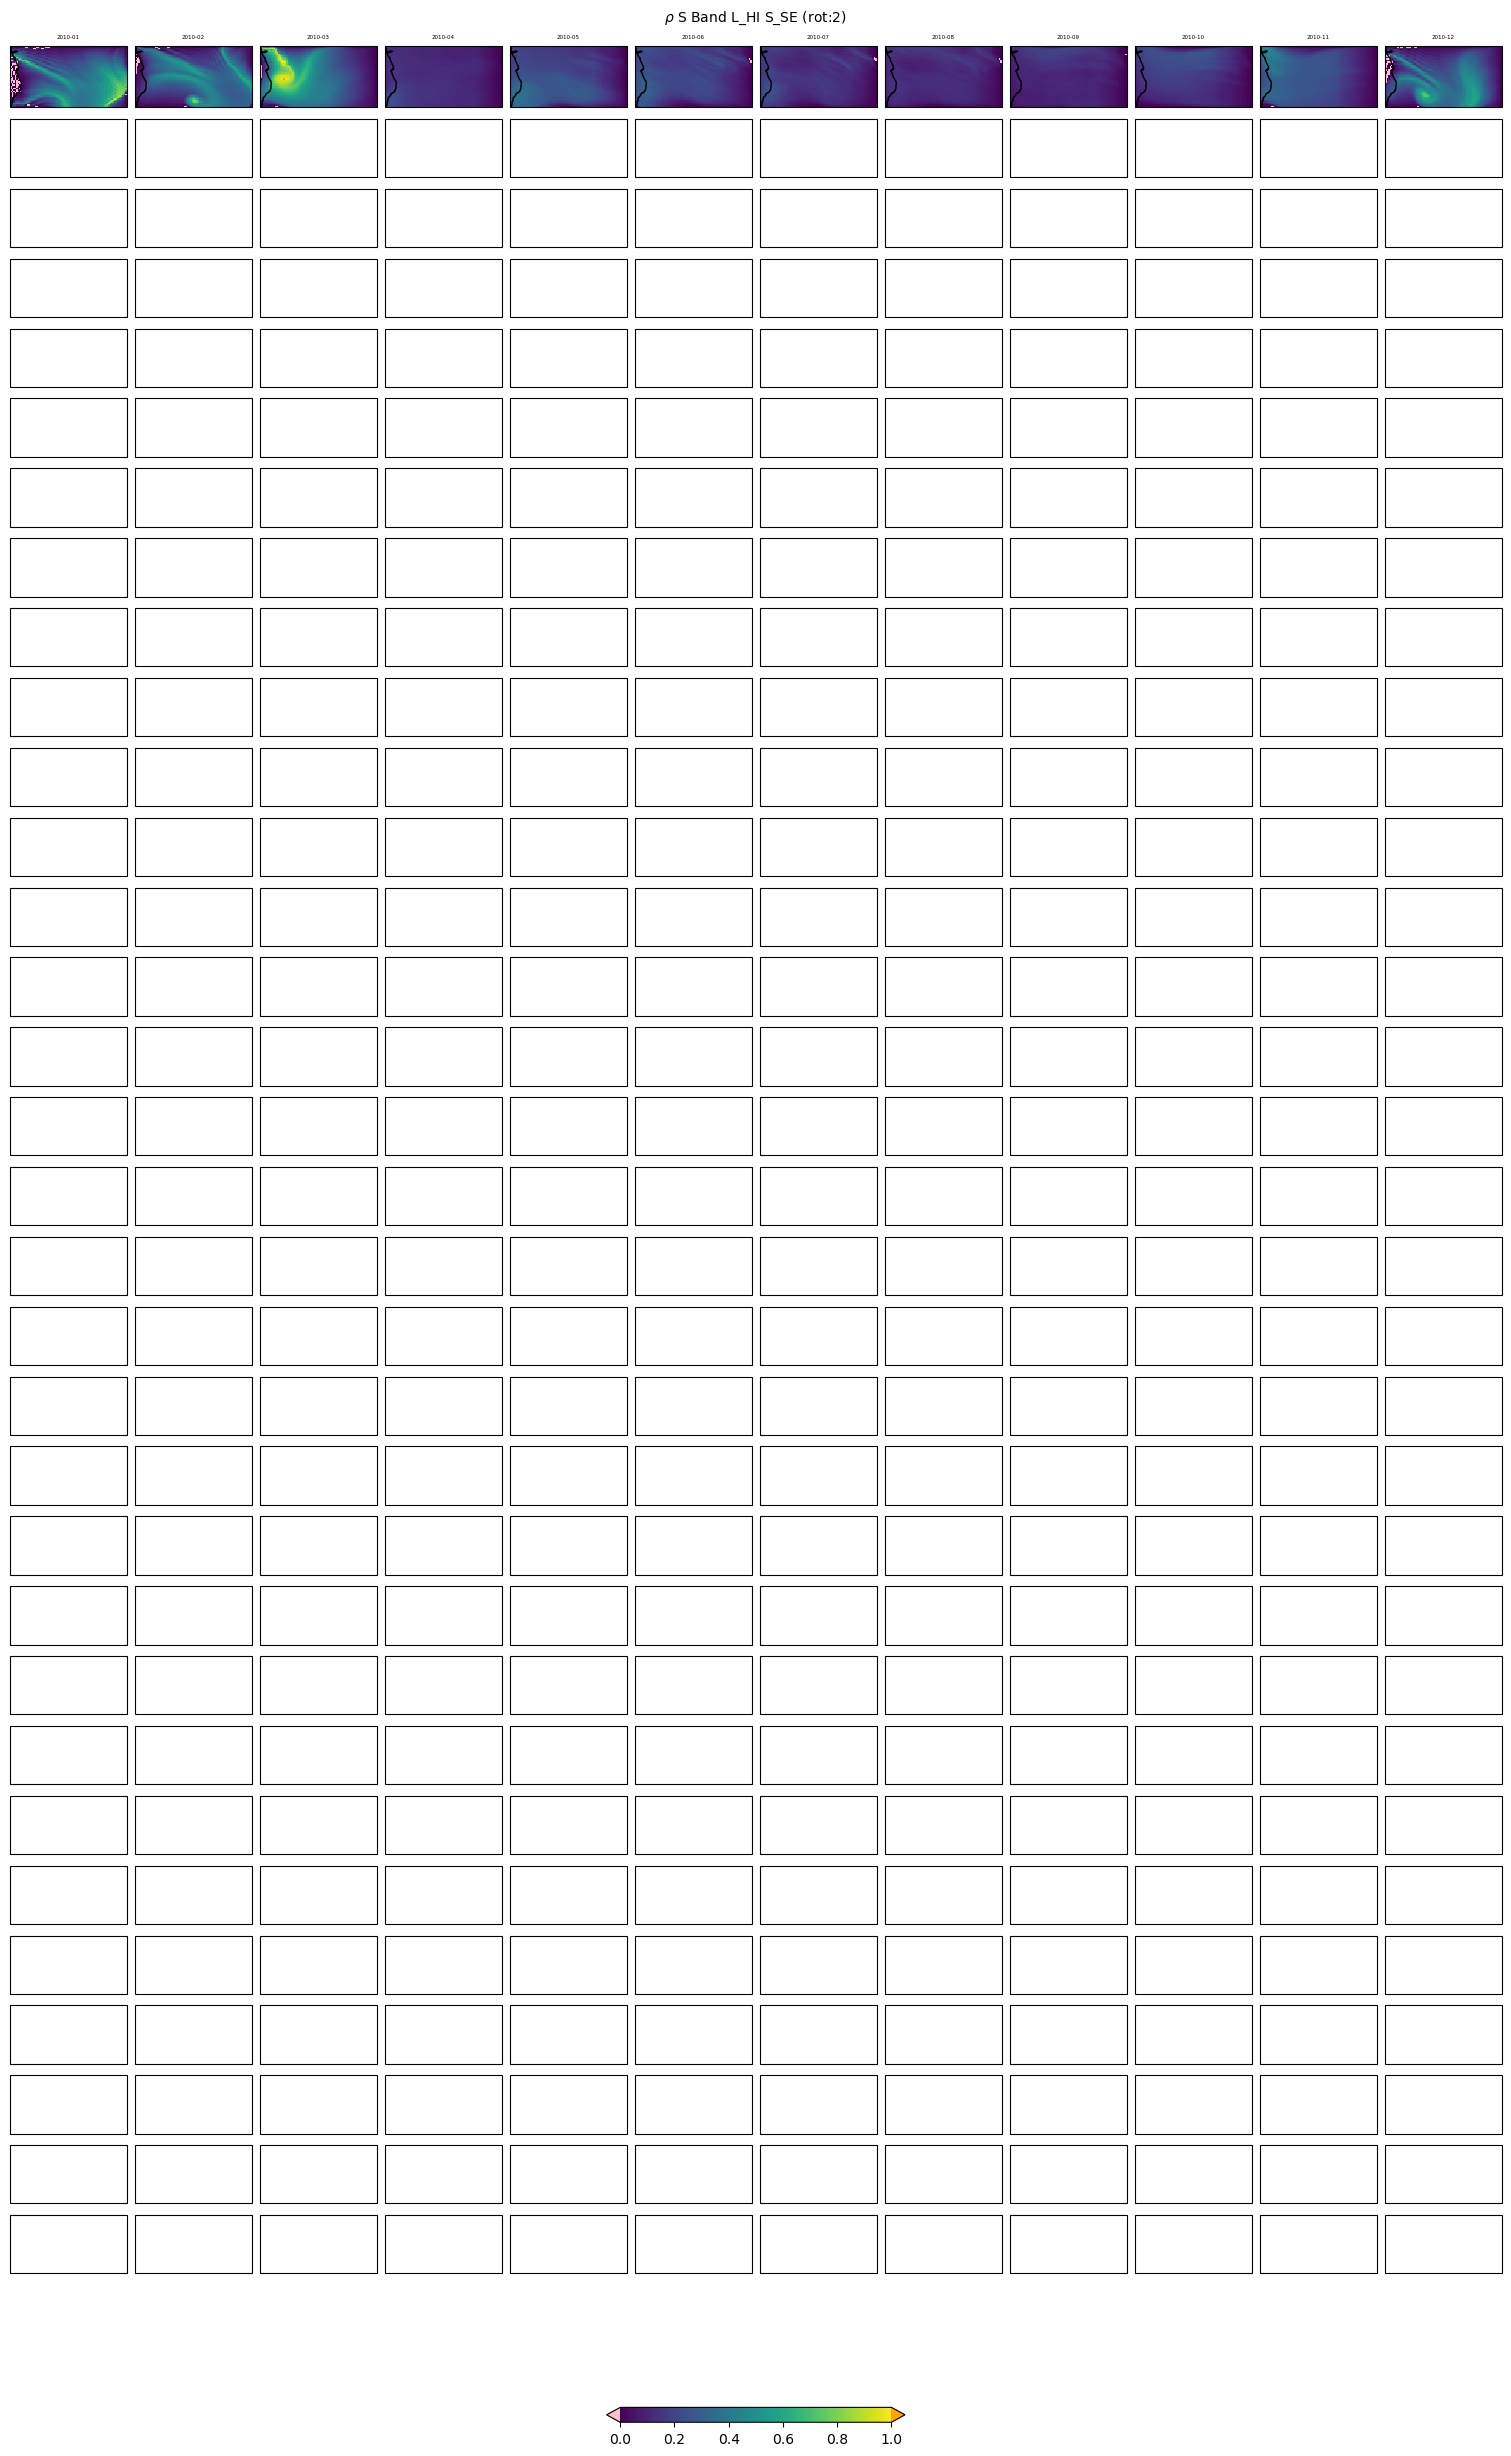

<Figure size 640x480 with 0 Axes>

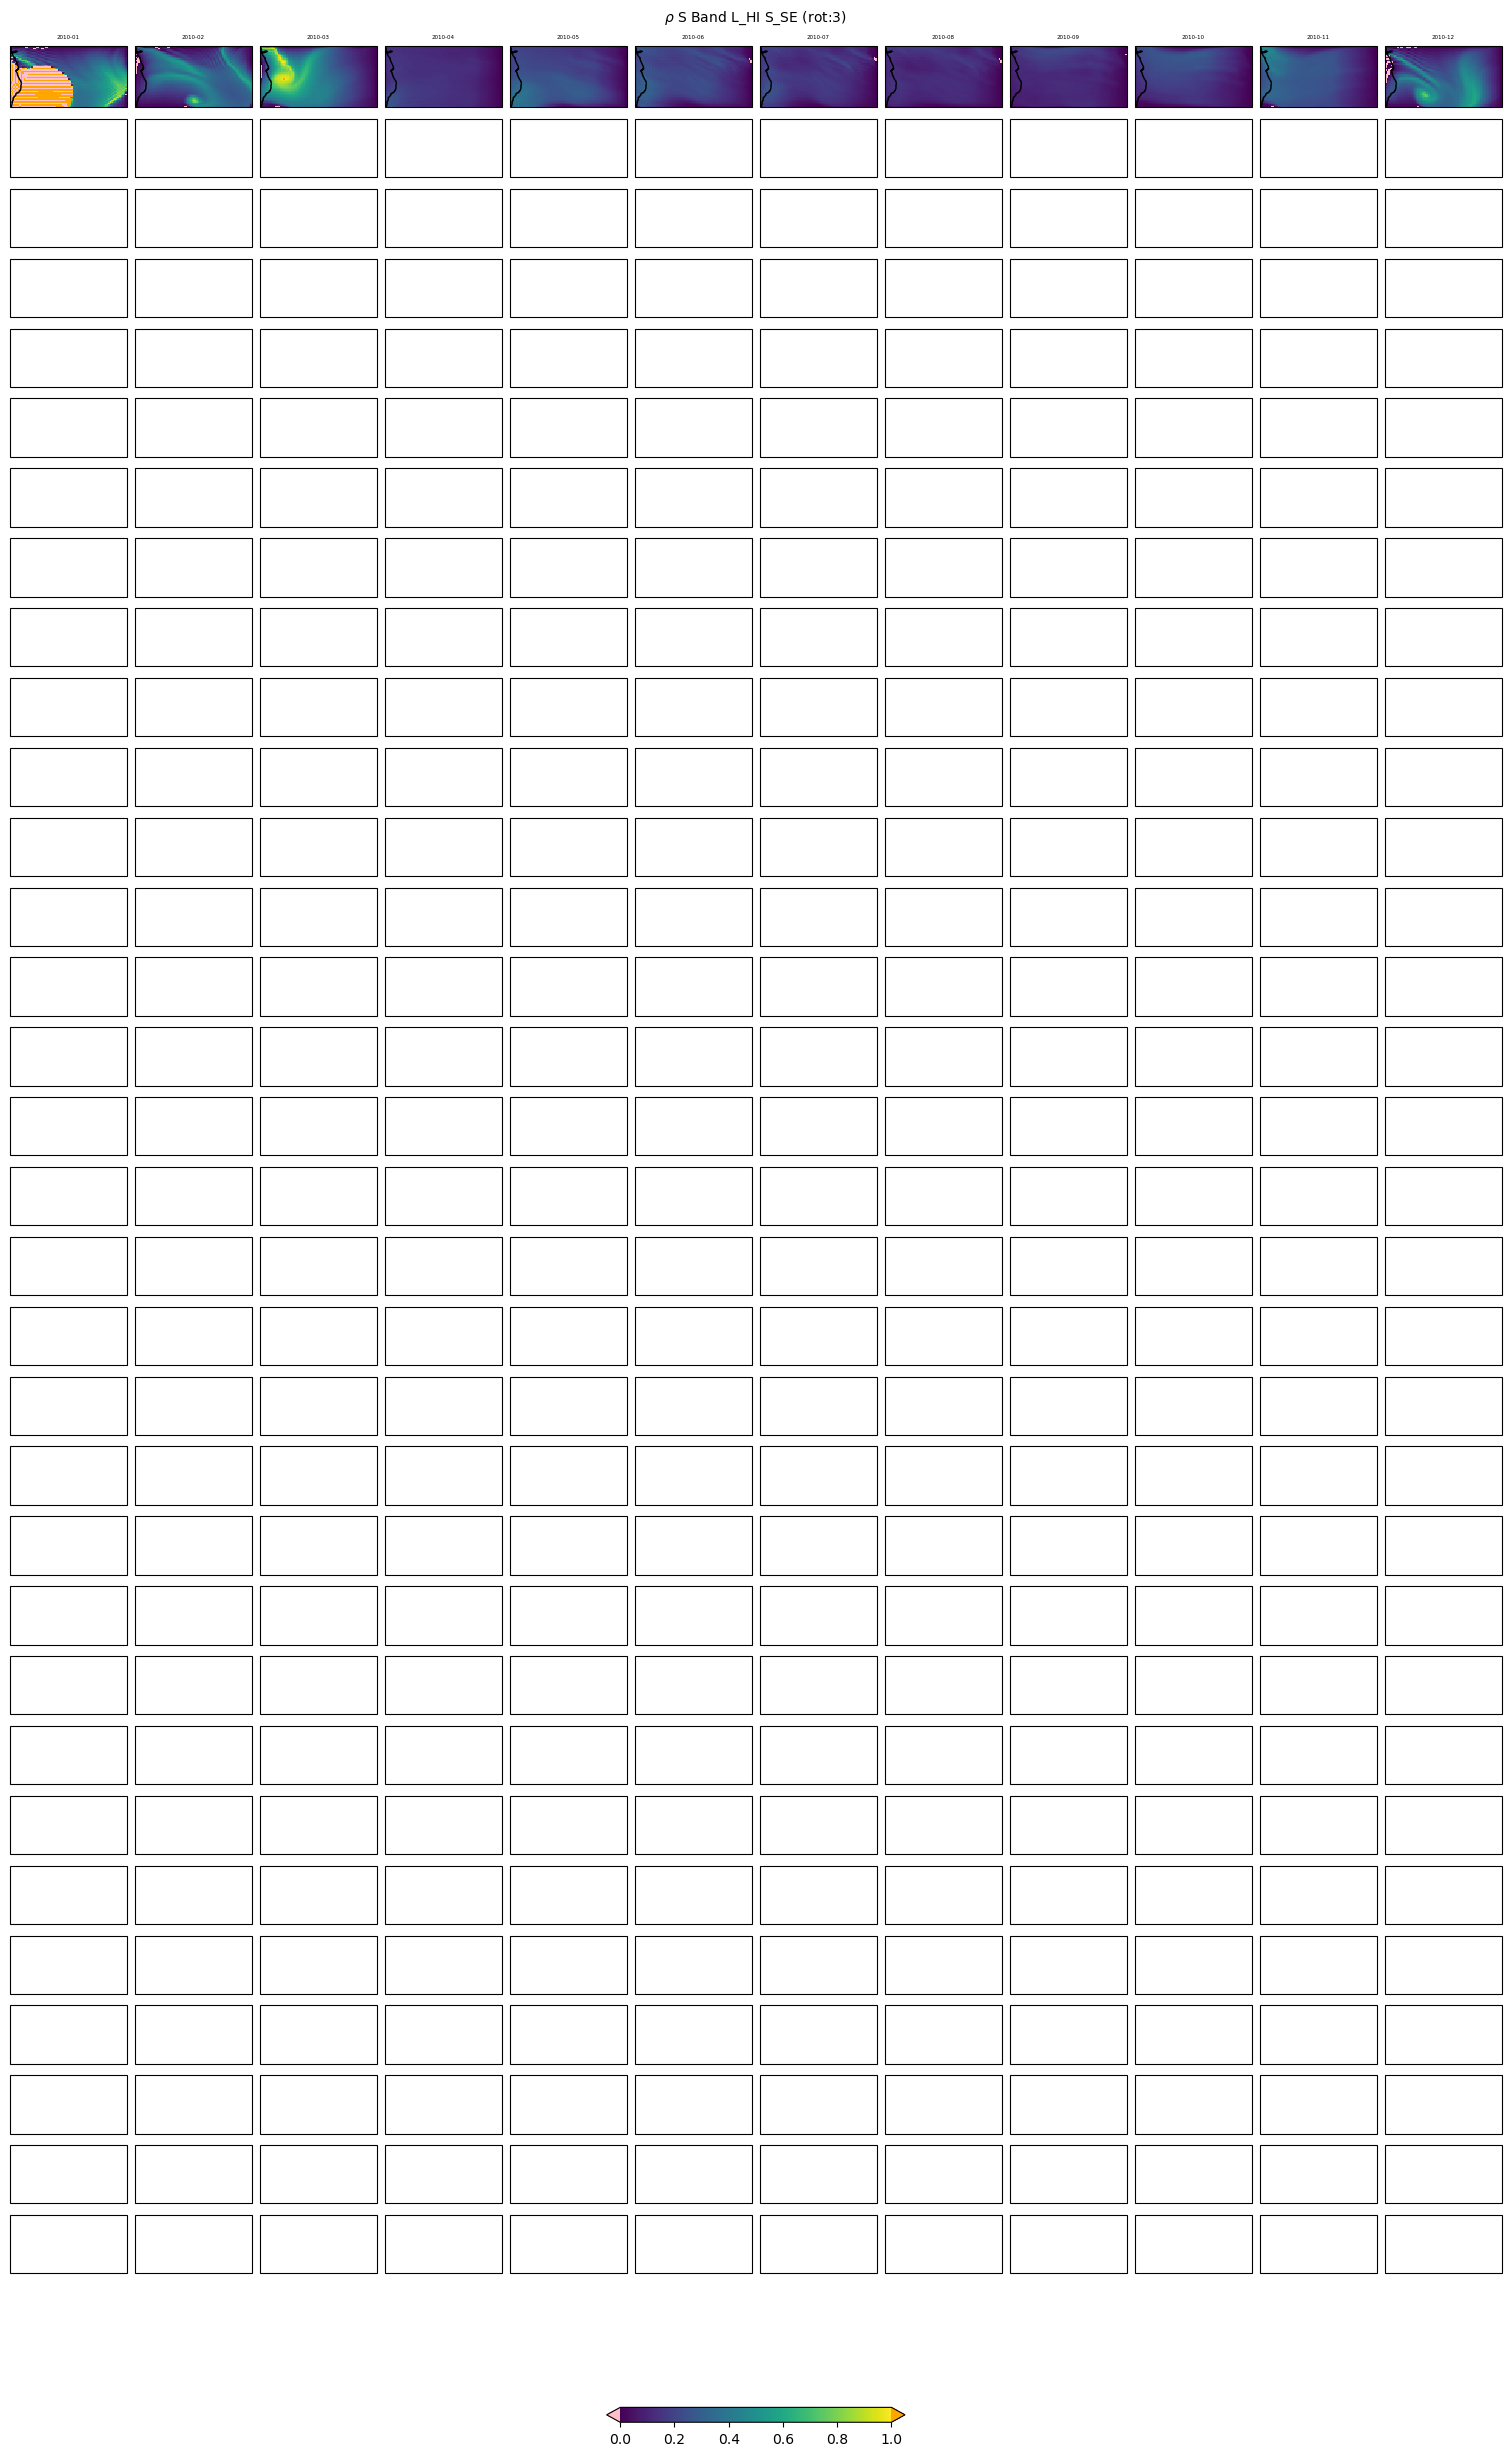

<Figure size 640x480 with 0 Axes>

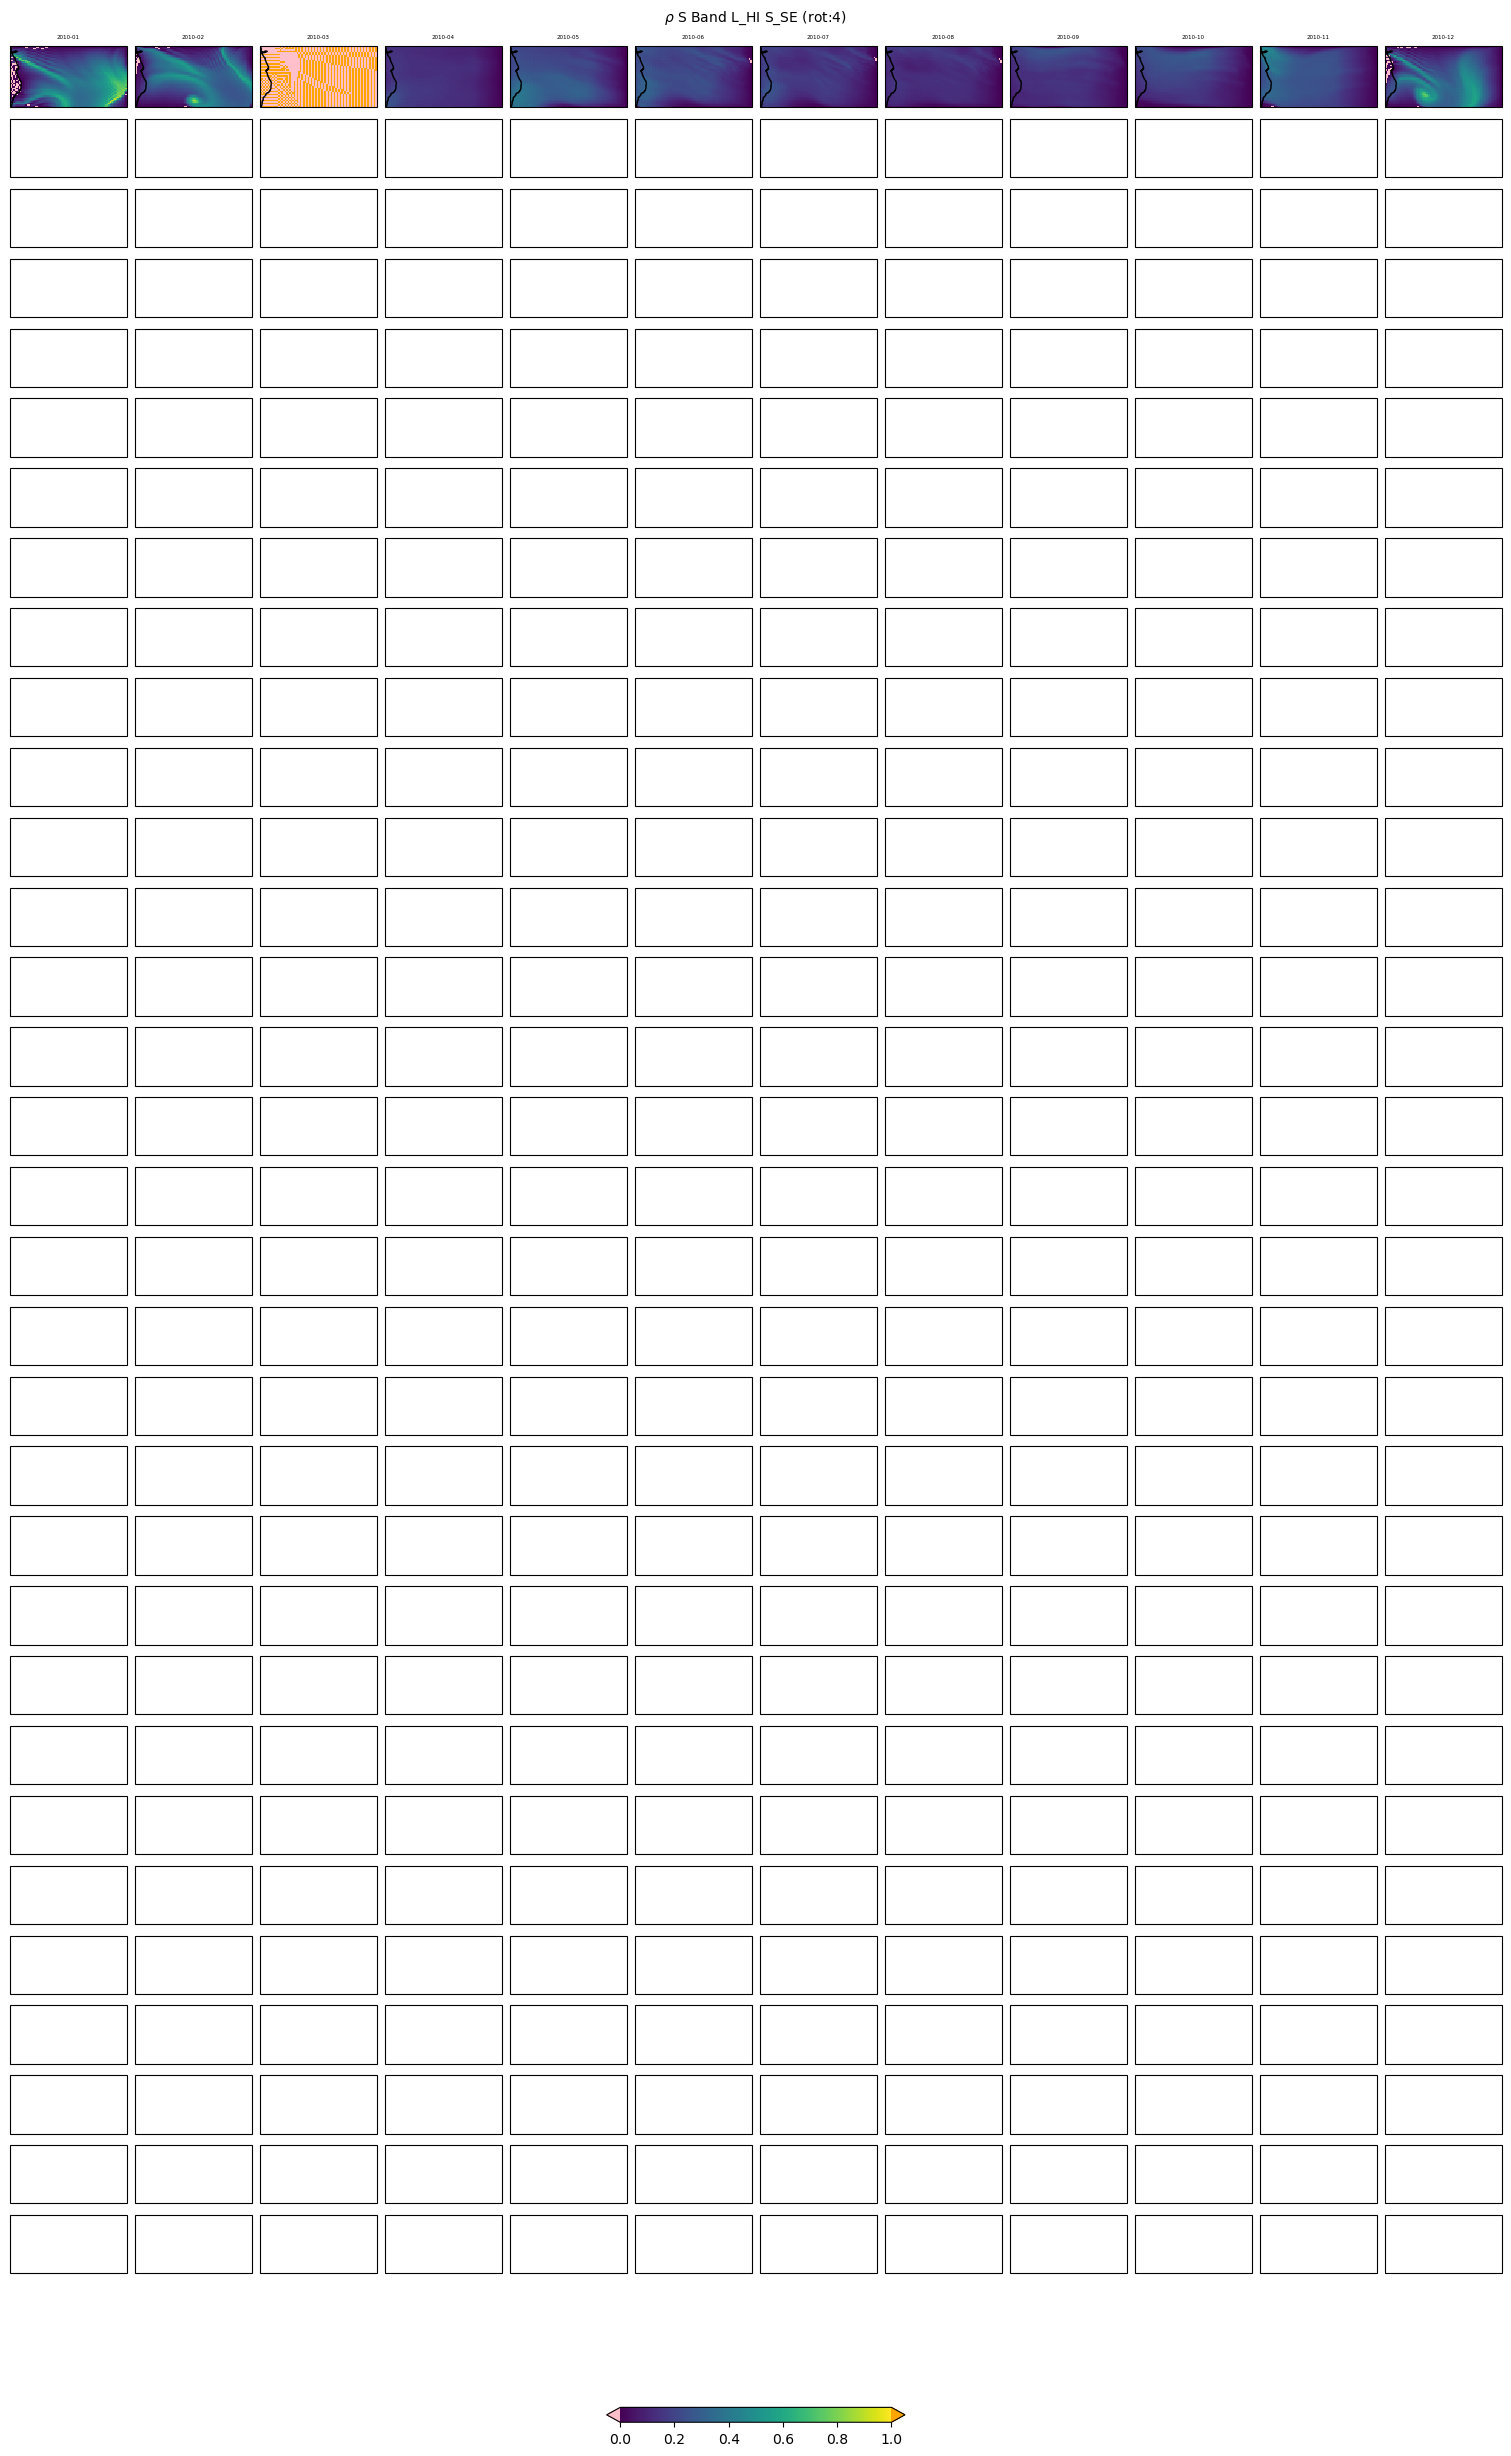

<Figure size 640x480 with 0 Axes>

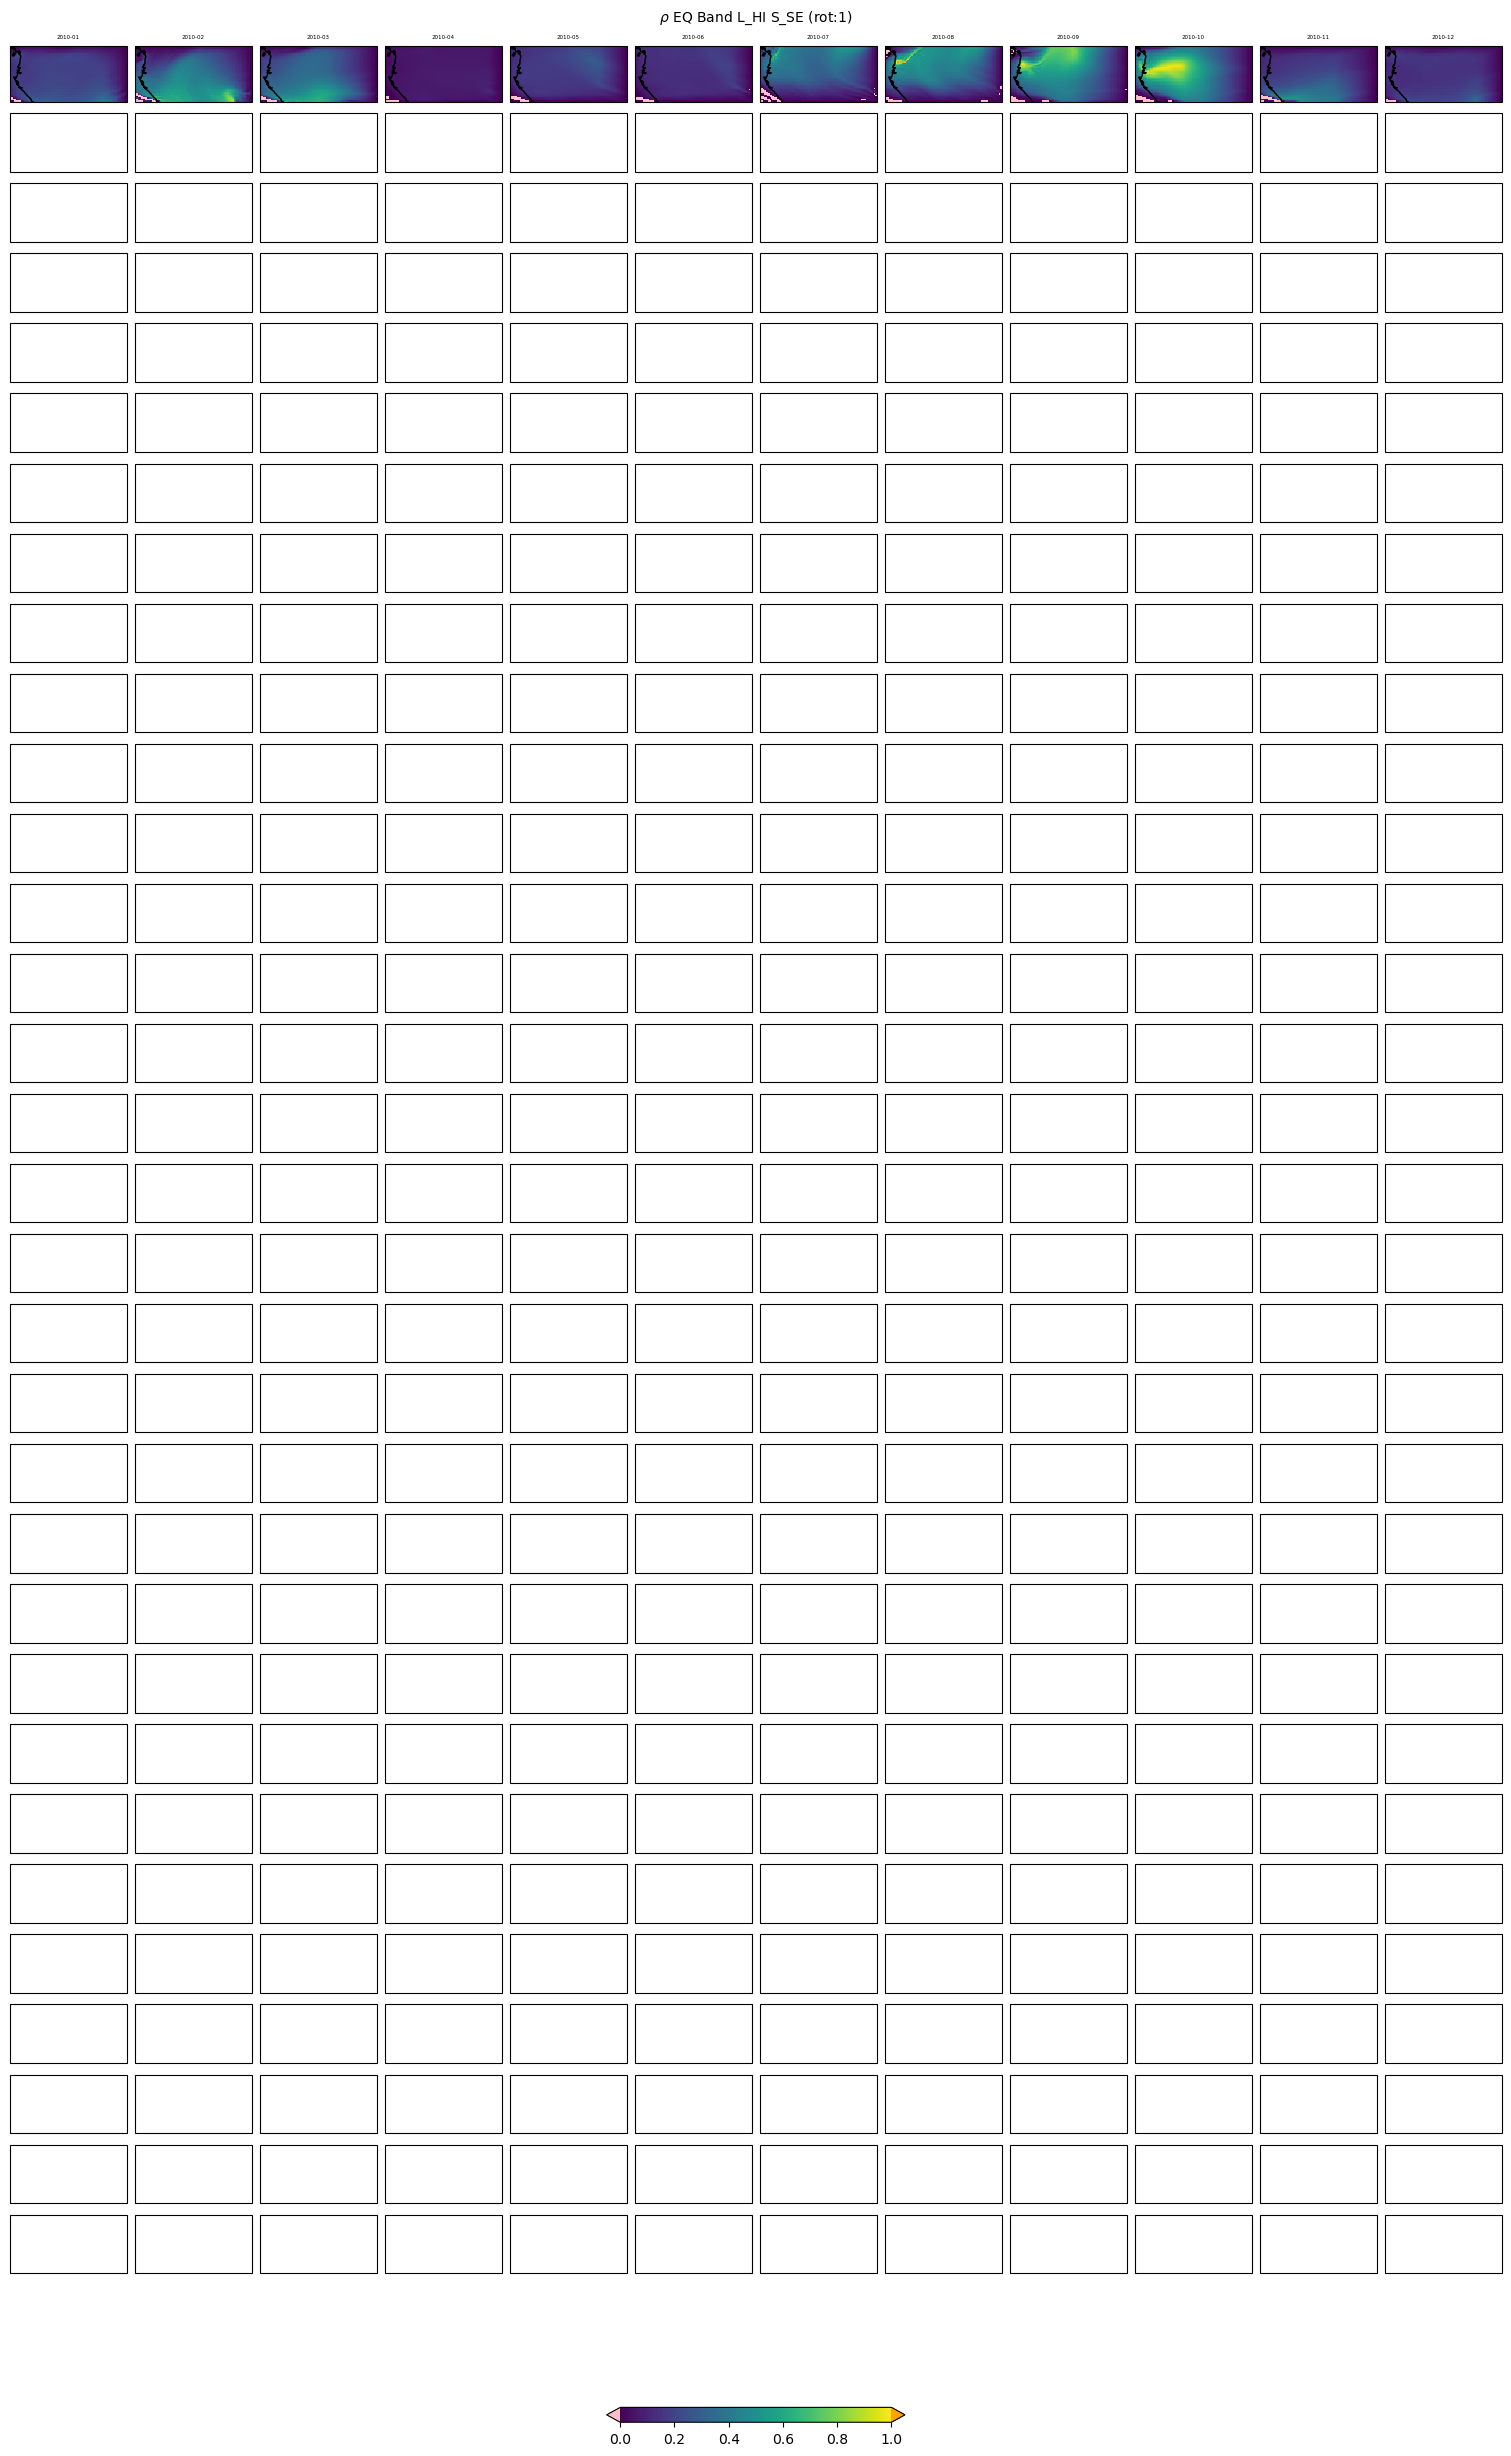

<Figure size 640x480 with 0 Axes>

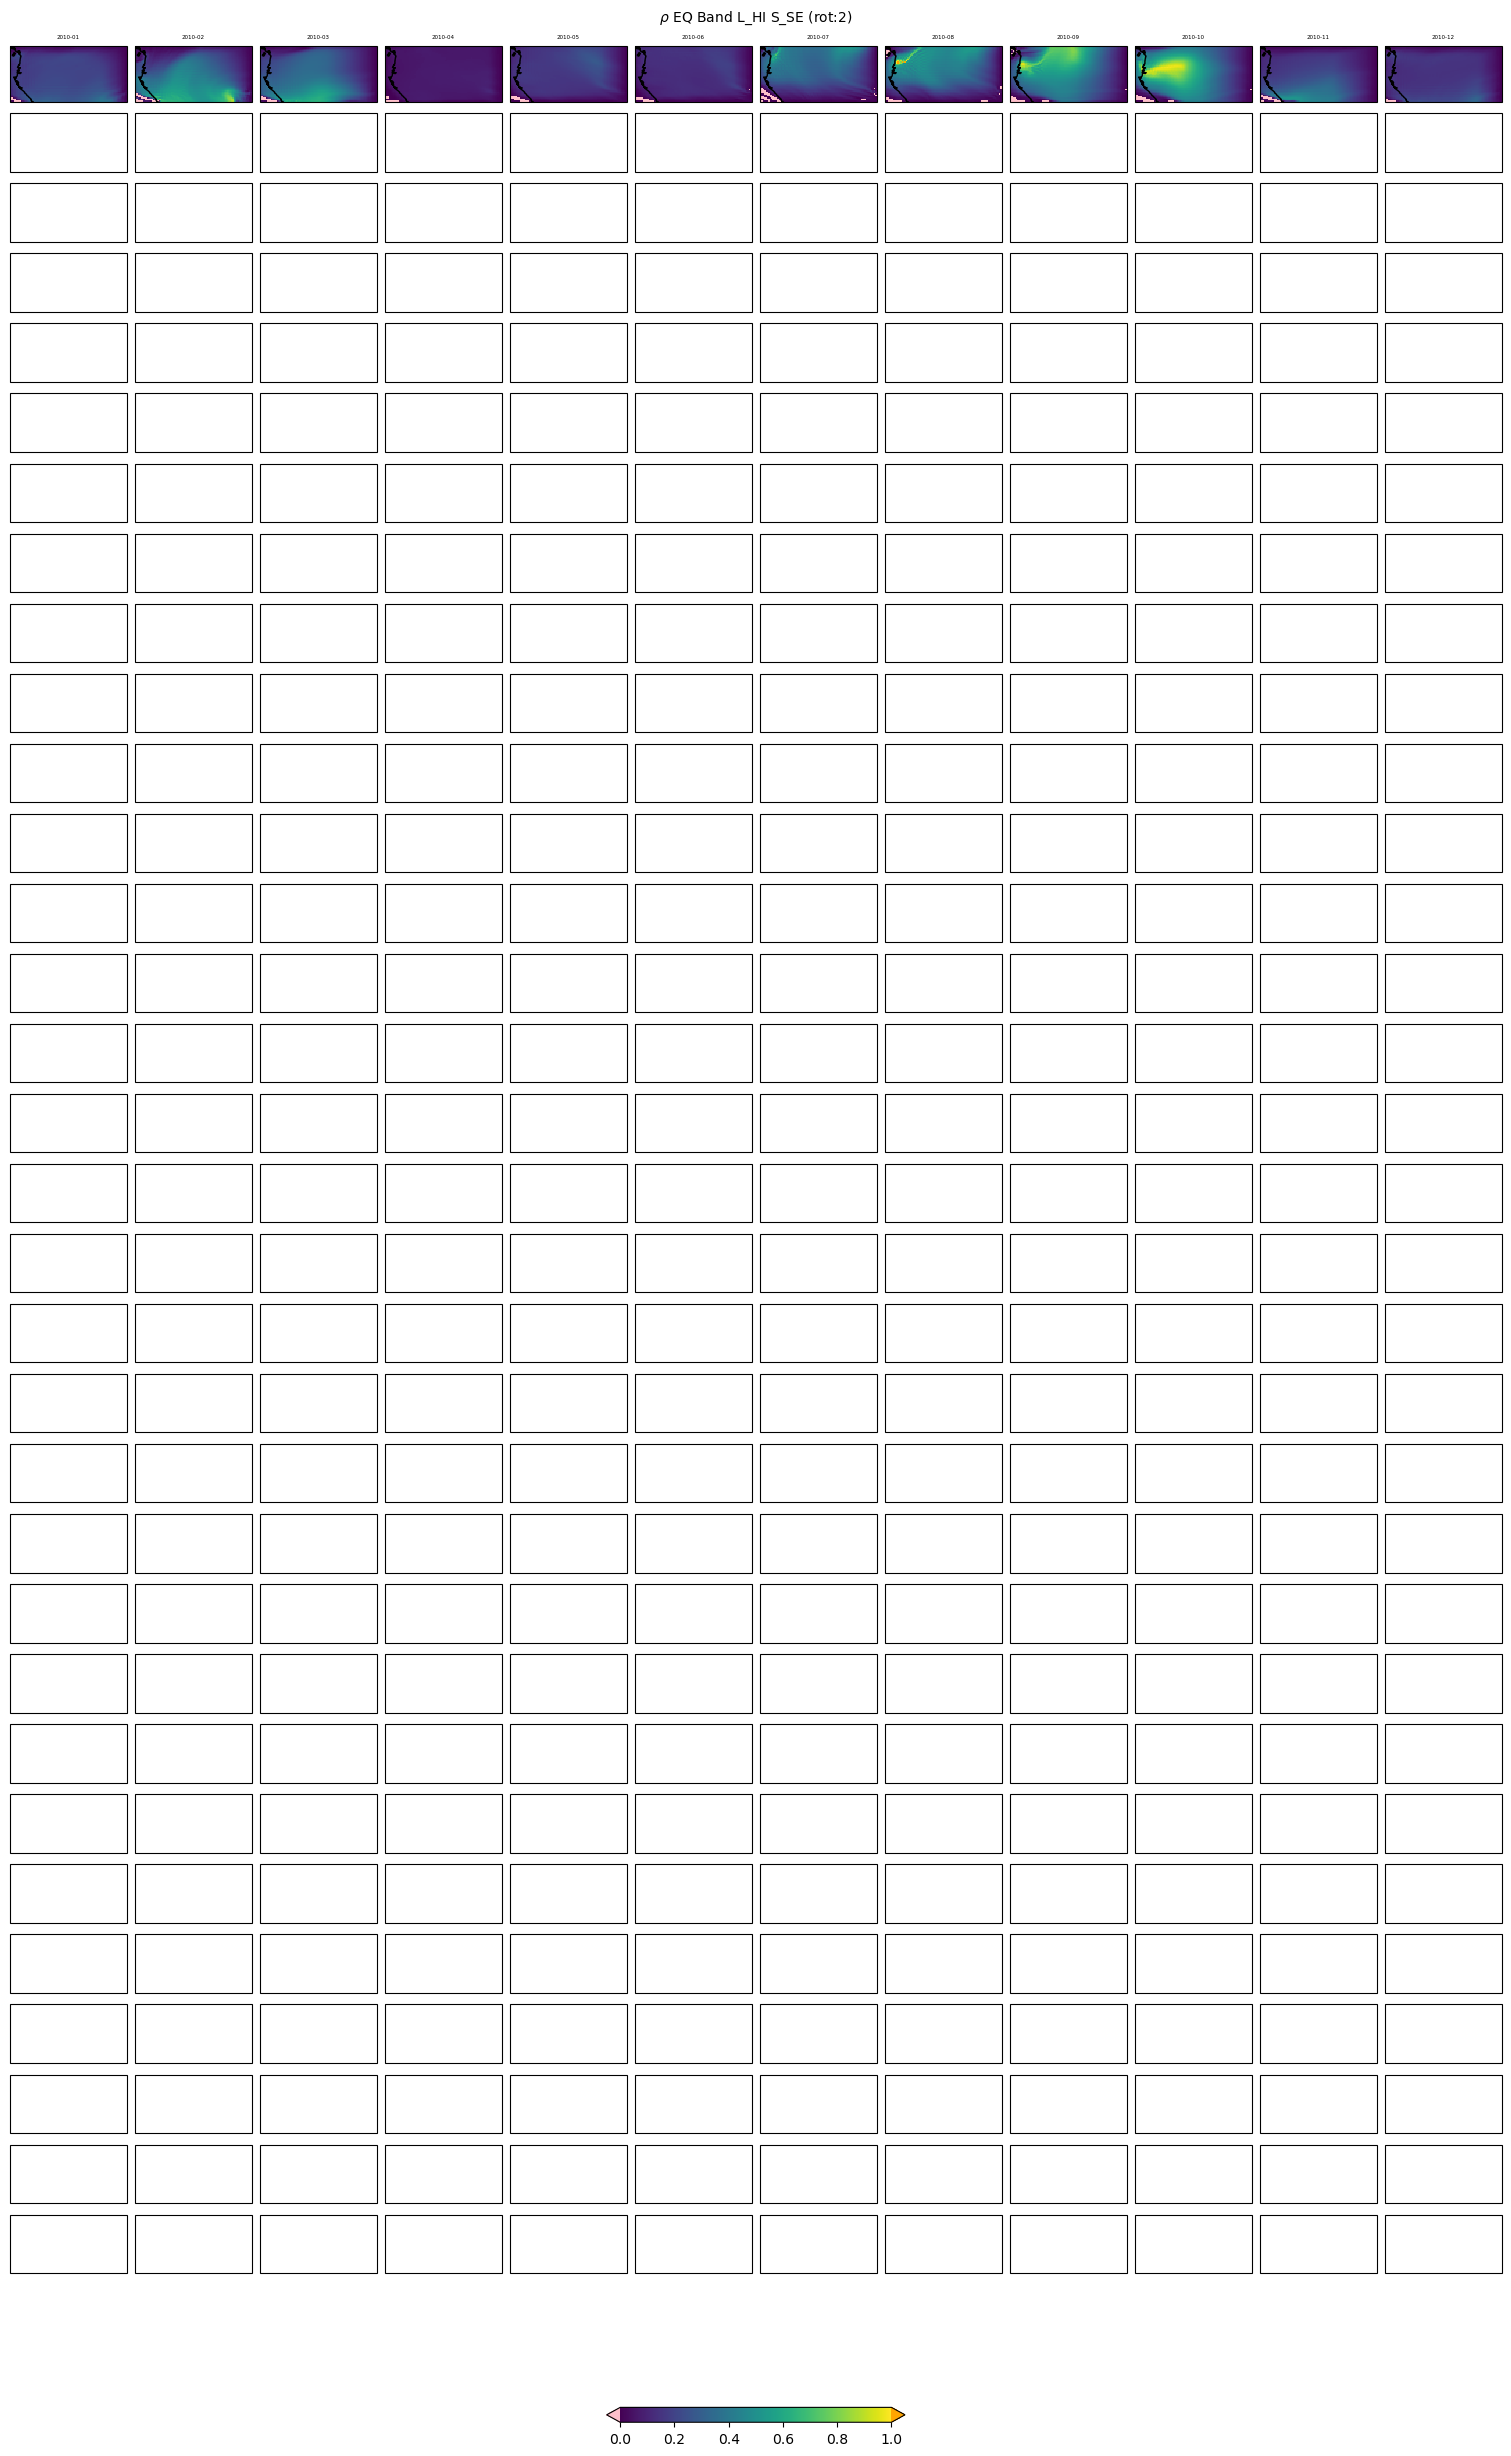

<Figure size 640x480 with 0 Axes>

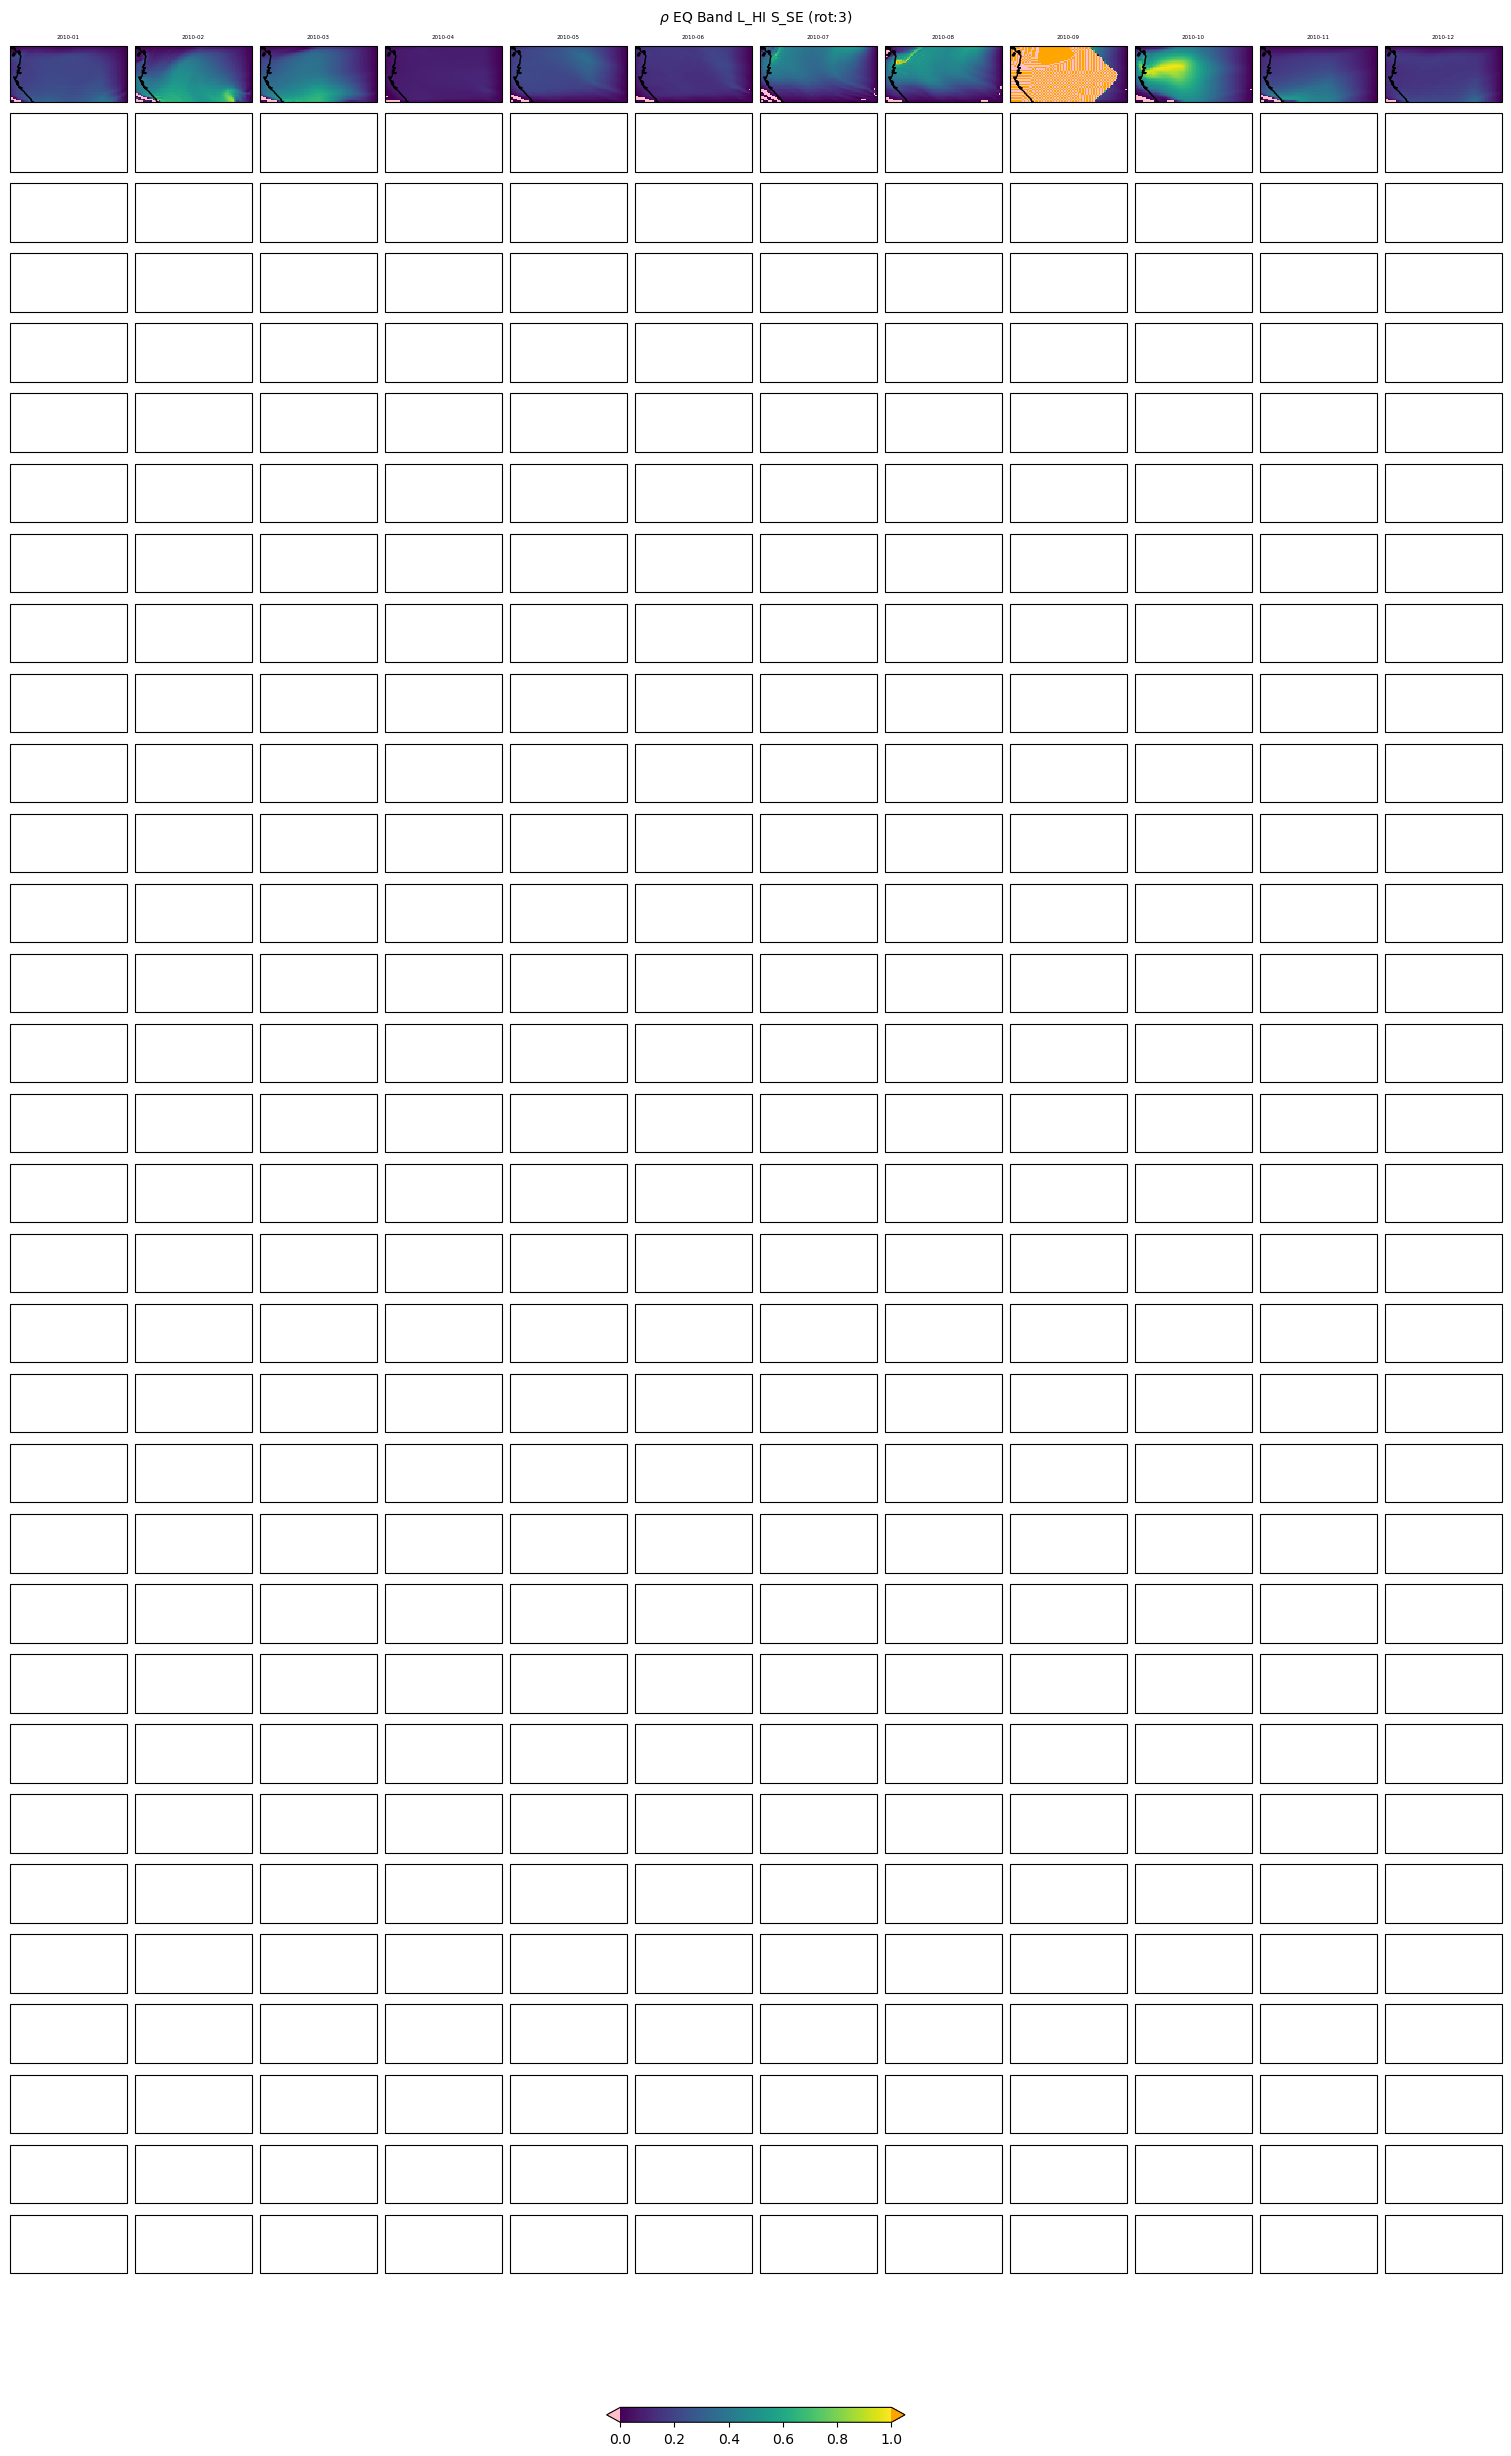

<Figure size 640x480 with 0 Axes>

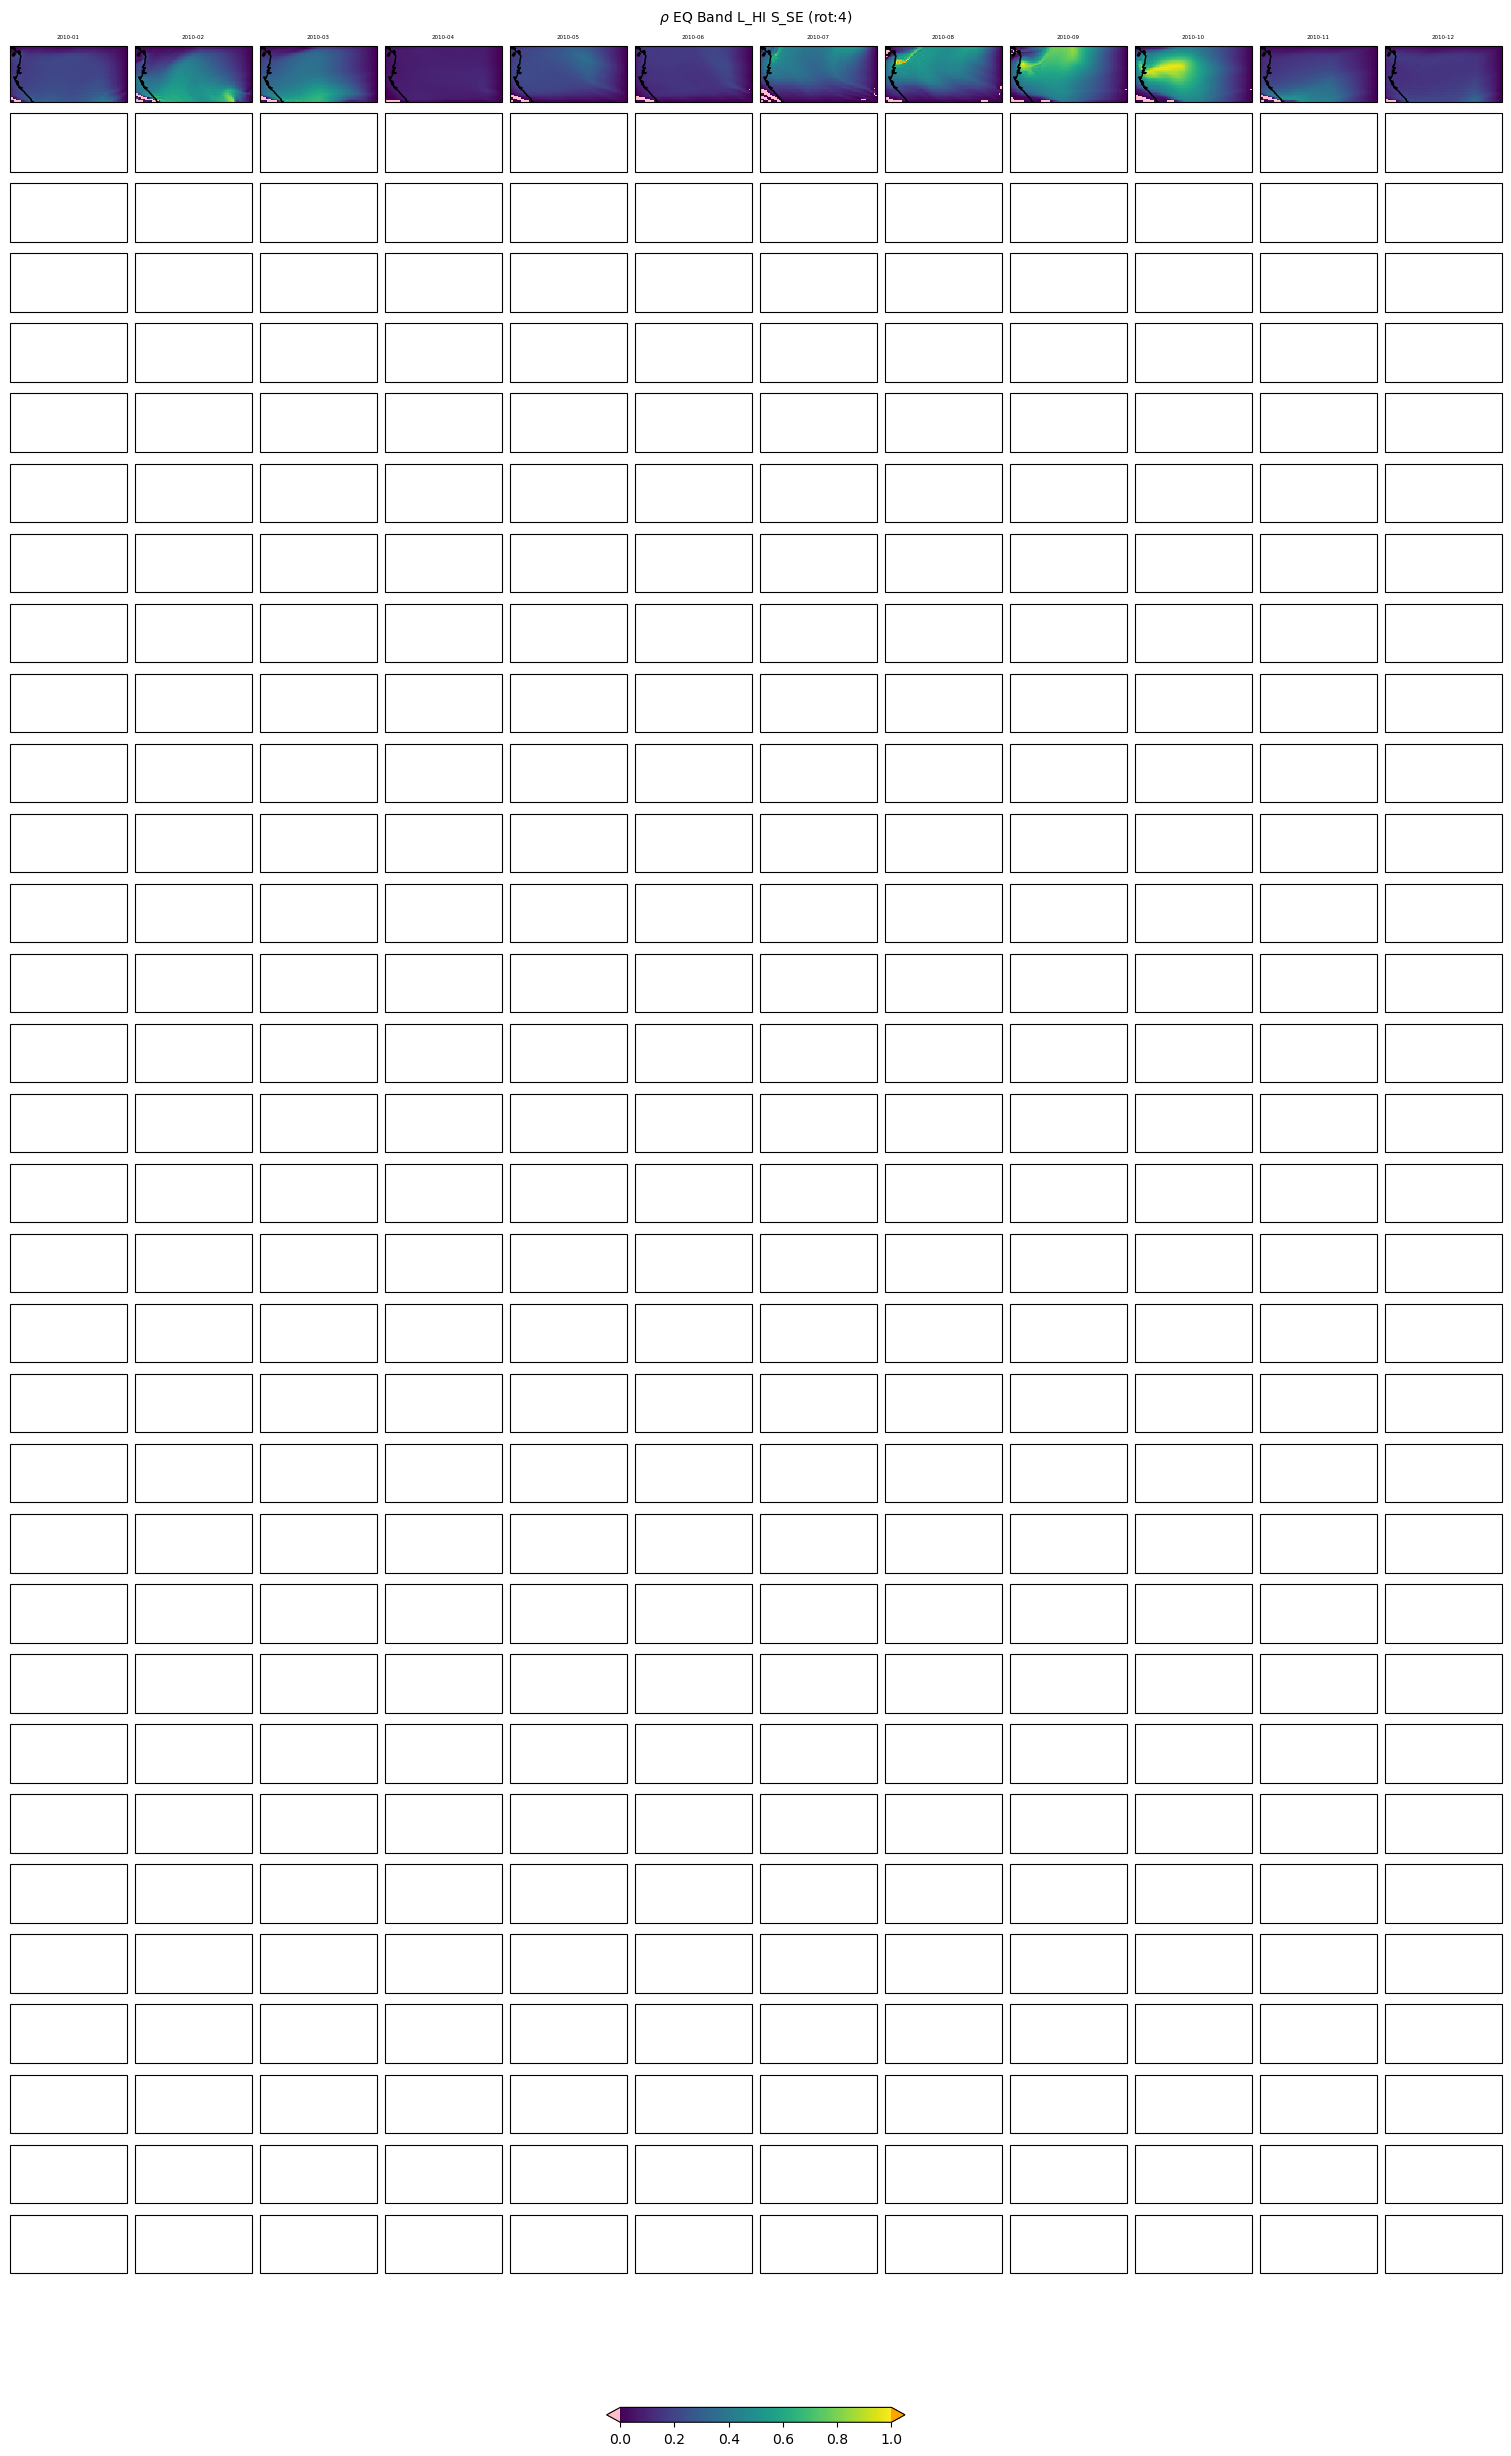

<Figure size 640x480 with 0 Axes>

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=12
nrows=32
h = nrows
w = ncols
cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for B in ['N','S','EQ']:
    for r in np.arange(1,5):

        # Define the figure and each axis for the 3 rows and 3 columns
        fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                                subplot_kw={'projection': ccrs.PlateCarree()},
                                gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                                layout="constrained",
                                figsize=(15,24))
        
        # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
        axs=axs.flatten()
        
        RHO = rho_xarr[B]['rho'].sel(rot=r)
        mtime = RHO['time']
        ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)
        
        #Loop over all of the models
        for i,T in enumerate(mtime):
        
                # Select the week 1 forecast from the specified model
                data=RHO.sel(time=T)
        
                # Contour plot
                cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                                   data.values,
                                   vmin=0.0,vmax=1.0,
                                   #levels=13,
                                   #extend='max',
                                   cmap=cmap,
                                   #aspect= ap,
                                   rasterized=True,
                                   transform = ccrs.PlateCarree())
        
                # Title each subplot with the name of the model
                axs[i].set_title(str(data["time.year"].values)+"-"+str("{:02d}".format(data["time.month"].values)),
                         fontsize=4)
        
                # Draw the coastines for each subplot
                axs[i].coastlines()
        
        # Adjust the location of the subplots on the page to make room for the colorbar
        fig.subplots_adjust(hspace=0,wspace=-0.5)
        #plt.tight_layout()
        
        # Add a colorbar axis at the bottom of the graph
        #cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])

        # Draw the colorbar
        #cbar=fig.colorbar(cs,ax=cbar_ax,extend='both')#,shrink=0.5)
        cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                            #location="bottom",
                            shrink=0.2,extend="both",fraction=0.2)
        
        # Add a big title at the top
        plt.suptitle("$\\rho$ "+B+" Band "+L_NAME+" "+S_NAME+" (rot:"+str(r)+")", fontsize=10,y=1.01,x=0.5)
        plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rot_"+str(r)+".png",bbox_inches="tight",dpi=200)
        plt.show()
        plt.clf()
        